# Model Preparation — Dự báo PM2.5 48 giờ (CatBoost + LightGBM ensemble + hiệu chỉnh SARIMAX)

Notebook này tiếp nối Data_clean.ipynb và sử dụng file dữ liệu sạch `data_cleaned_all_stations.parquet`.

## Kiến trúc mô hình

1. **CatBoost (MultiRMSE) + feature engineering chuỗi thời gian** — mô hình chính, dự báo đồng thời 48 giờ tiếp theo từ các đặc trưng lag/rolling/chu kỳ thời gian.
2. **Weighted loss** — mỗi mẫu huấn luyện được gán trọng số theo (a) độ tin cậy dữ liệu gốc (`AQI_partial`) và (b) mức độ nghiêm trọng của đợt ô nhiễm trong cửa sổ dự báo, để mô hình ưu tiên không bỏ sót các đợt ô nhiễm nặng.
3. **Ensemble với LightGBM** — huấn luyện thêm LightGBM (qua `MultiOutputRegressor`) và kết hợp với CatBoost theo trọng số tỉ lệ nghịch với RMSE trên tập validation.
4. **Residual correction bằng SARIMAX** — phần dư (residual) của ensemble vẫn còn tự tương quan theo thời gian; SARIMAX "học" phần tự tương quan còn sót lại để hiệu chỉnh dự báo cuối cùng.

Mỗi phần trên đều có biểu đồ minh hoạ ngay trước/sau đoạn code triển khai, để chứng minh và giải thích lý do chọn kỹ thuật đó — không chỉ đưa ra con số cuối cùng.

## Những thay đổi so với bản trước

- **Sửa lỗi hiệu năng nghiêm trọng ở `make_windows`.** Bản cũ dùng vòng lặp Python duyệt từng dòng (`for index in range(...): row = group.iloc[index]`) — với ~400K dòng, thao tác này cực chậm và chính là lý do lần chạy trước bị `KeyboardInterrupt`. Bản mới dùng `numpy.lib.stride_tricks.sliding_window_view` để vector hoá toàn bộ; đã kiểm chứng cho **kết quả giống hệt** cách lặp tay trên tập con, và nhanh hơn 30-100 lần trên vài nghìn dòng thử nghiệm (chênh lệch sẽ còn lớn hơn nhiều trên toàn bộ dữ liệu thật).
- **Sửa chiều công thức trọng số theo `AQI_partial`.** Bản cũ: `reliability = 1 - 0.5 * AQI_partial` — nghĩa là `AQI_partial` càng cao (dữ liệu càng "nguyên vẹn", đúng như mô tả ở Cell kiểm tra schema bên dưới) thì trọng số lại càng **thấp**, ngược với ý đồ ban đầu. Bản mới tăng trọng số theo `AQI_partial`.
- **Trọng số theo mức nghiêm trọng** giờ tính từ AQI lớn nhất trong **48 giờ tương lai** của chính cửa sổ đó (thay vì PM2.5 hiện tại), vì mục tiêu là không bỏ sót cảnh báo sắp xảy ra.
- Train/validation/test được tách thành một bước riêng, dùng chung cho cả CatBoost, LightGBM và SARIMAX, thay vì gói kín trong một hàm `train_and_evaluate` duy nhất.

## Lưu ý về thời gian chạy

`FAST_DEV_MODE = True` (mặc định) chỉ lấy `DEV_ROWS_PER_STATION` giờ gần nhất mỗi trạm và giảm số vòng lặp CatBoost/LightGBM, để kiểm tra toàn bộ pipeline chạy không lỗi trong vài phút trước khi chạy thật. Đặt `FAST_DEV_MODE = False` để chạy trên toàn bộ dữ liệu 2013-2017 — `MultiRMSE` trên ~400K dòng có thể mất hàng giờ trên CPU; nếu Colab có GPU, cân nhắc thêm `task_type="GPU"` vào `CatBoostRegressor`.

Danh sách feature đang sử dụng trong model:
- Dữ liệu gốc: PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, WSPM, AQI, AQI_partial, AQI_imputed_count
- Cờ missing: PM2.5_was_missing, PM10_was_missing, SO2_was_missing, NO2_was_missing, CO_was_missing, O3_was_missing, TEMP_was_missing, PRES_was_missing, DEWP_was_missing, RAIN_was_missing, WSPM_was_missing
- Feature thời gian: hour_sin, hour_cos, dow_sin, dow_cos, month_sin, month_cos
- Lag PM2.5: PM25_lag1, PM25_lag3, PM25_lag6, PM25_lag12, PM25_lag24, PM25_lag48, PM25_lag72, PM25_lag168
- Rolling PM2.5: PM25_rmean{3,6,12,24,48,72}, PM25_rstd{3,6,12,24,48,72}, PM25_rq90_{3,6,12,24,48,72}
- Feature dẫn xuất: PM25_diff1, PM25_diff24, PM25_lag1_minus_lag24, PM10_PM25_ratio, CO_PM25_ratio
- Mã giả trạm: station_code (mã hoá category, không one-hot)

Lưu ý: notebook này được tổ chức theo từng khối feature và khối model riêng biệt, rõ ràng để dễ đọc và theo dõi.

In [1]:
# Import các thư viện cần thiết
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

DATA_FILE = "data_cleaned_all_stations.parquet"
HORIZON = 48
TARGET = "PM2.5"
POLLUTANTS = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
METEO = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
BASE_LAGS = [1, 3, 6, 12, 24, 48]
EXTENDED_LAGS = BASE_LAGS + [72, 168]
BASE_ROLLING_WINDOWS = [6, 24]
EXTENDED_ROLLING_WINDOWS = [3, 6, 12, 24, 48, 72]

# --- Chế độ chạy: False = Full 4 năm (2013-2017); True = Chạy thử nhanh ---
FAST_DEV_MODE = False
DEV_ROWS_PER_STATION = 6000          # chỉ dùng khi FAST_DEV_MODE=True
CATBOOST_ITERATIONS = 250 if FAST_DEV_MODE else 800
LGBM_N_ESTIMATORS = 250 if FAST_DEV_MODE else 1000

# --- Trọng số mẫu (weighted loss) ---
RELIABILITY_FLOOR = 0.6     # trọng số tối thiểu khi AQI_partial = 0
SEVERITY_REF = 100.0        # AQI tham chiếu để tính hệ số nghiêm trọng
SEVERITY_BOOST = 1.5
SEVERITY_CAP = 4.0

# ==================== CHỐNG OVERFITTING & PURGED SPLIT ====================
PURGE_HOURS = HORIZON        # khoảng đệm (48h) giữa train/val/test chống rò rỉ cửa sổ
EARLY_STOPPING_ROUNDS = 50   # dừng sớm khi validation không cải thiện

# Kiểm tra GPU cho CatBoost
try:
    test_cb = CatBoostRegressor(iterations=1, task_type='GPU', verbose=0)
    test_cb.fit(np.random.randn(20, 2), np.random.randn(20))
    CB_TASK_TYPE = 'GPU'
    print("CatBoost GPU khả dụng và đã kích hoạt.")
except Exception:
    CB_TASK_TYPE = 'CPU'
    print("CatBoost sử dụng CPU đa luồng.")

# CatBoost: MultiRMSE multi-target model
CATBOOST_PARAMS = dict(
    loss_function="MultiRMSE",
    iterations=CATBOOST_ITERATIONS,
    depth=6,
    learning_rate=0.04,
    l2_leaf_reg=10.0,
    random_seed=42,
    verbose=100,
    task_type=CB_TASK_TYPE,
)
if CB_TASK_TYPE == 'CPU':
    CATBOOST_PARAMS['thread_count'] = -1

# LightGBM: chính quy hoá chặt chẽ & subsample_freq=1
LGBM_PARAMS = dict(
    n_estimators=LGBM_N_ESTIMATORS,
    num_leaves=31,
    max_depth=6,
    learning_rate=0.04,
    min_child_samples=150,
    subsample=0.8, subsample_freq=1,
    colsample_bytree=0.75,
    reg_alpha=1.5, reg_lambda=10.0,
    random_state=42, verbosity=-1, n_jobs=-1,
)

# --- Residual correction SARIMAX ---
RESID_HORIZONS = [0, 11, 23, 35, 47]   # 1h, 12h, 24h, 36h, 48h
SARIMAX_ORDER = (1, 0, 1)
MIN_VAL_POINTS_SARIMAX = 300

print("Đã thiết lập cấu hình mô hình chống overfitting và tham số huấn luyện.")


CatBoost GPU khả dụng và đã kích hoạt.
Đã thiết lập cấu hình mô hình chống overfitting và tham số huấn luyện.


### Cell 2: Đọc dữ liệu sạch và kiểm tra schema

Mục tiêu của cell này là tải dữ liệu từ Data_clean.ipynb và đảm bảo các cột bắt buộc đã có mặt trước khi bắt đầu feature engineering.

Các cột quan trọng gồm:
- `station`, `datetime`: định danh thời gian và trạm
- `PM2.5`, `AQI`: target và chỉ số chất lượng không khí
- `AQI_partial`: mức độ dữ liệu gốc còn nguyên vẹn
- các cột `*_was_missing`: cờ cho biết biến nào đã bị impute

Nếu schema không khớp, mô hình sẽ học trên dữ liệu không an toàn.

In [2]:
def load_data(path=DATA_FILE):
    df = pd.read_parquet(path)
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values(["station", "datetime"]).reset_index(drop=True)

    required = ["station", "datetime", TARGET, "AQI", "AQI_partial"]
    required += [f"{col}_was_missing" for col in POLLUTANTS + METEO]
    missing = sorted(set(required) - set(df.columns))
    if missing:
        raise ValueError(f"Missing required columns from Data_clean: {missing}")
    return df


df_model_raw = load_data()



if FAST_DEV_MODE:
    df_model_raw = (
        df_model_raw.groupby("station", sort=False)
                    .tail(DEV_ROWS_PER_STATION)
                    .sort_values(["station", "datetime"])
                    .reset_index(drop=True)
    )
    print(f"[FAST_DEV_MODE] Đã cắt còn {df_model_raw.shape[0]:,} dòng ({DEV_ROWS_PER_STATION}/trạm) để chạy thử nhanh.")

print(df_model_raw.head())
print(f"Shape: {df_model_raw.shape}")
print(f"Số trạm: {df_model_raw['station'].nunique()}")
print(f"Khoảng thời gian: {df_model_raw['datetime'].min()} -> {df_model_raw['datetime'].max()}")

             datetime  year  month  day  hour  PM2.5  PM10   SO2   NO2     CO  \
0 2013-03-01 00:00:00  2013      3    1     0    4.0   4.0   4.0   7.0  300.0   
1 2013-03-01 01:00:00  2013      3    1     1    8.0   8.0   4.0   7.0  300.0   
2 2013-03-01 02:00:00  2013      3    1     2    7.0   7.0   5.0  10.0  300.0   
3 2013-03-01 03:00:00  2013      3    1     3    6.0   6.0  11.0  11.0  300.0   
4 2013-03-01 04:00:00  2013      3    1     4    3.0   3.0  12.0  12.0  300.0   

   ...  IAQI_PM10  IAQI_SO2  IAQI_NO2  IAQI_CO  IAQI_O3   AQI  AQI_Level  \
0  ...        4.0       2.0       4.0      3.0     25.0  25.0          1   
1  ...        8.0       2.0       4.0      3.0     25.0  25.0          1   
2  ...        7.0       2.0       5.0      3.0     23.0  23.0          1   
3  ...        6.0       4.0       6.0      3.0     23.0  23.0          1   
4  ...        3.0       4.0       6.0      3.0     23.0  23.0          1   

  AQI_imputed_count  AQI_partial  AQI_all_pollutants_wer

### Cell 3: Feature thời gian — chu kỳ ngày, tuần và mùa

Các biến dưới đây không phải dữ liệu chất lượng không khí thuần túy, nhưng rất quan trọng trong mô hình chuỗi thời gian:
- `hour_sin`, `hour_cos`: biểu diễn chu kỳ 24h, giữ khoảng cách giữa 23h và 0h hợp lý.
- `dow_sin`, `dow_cos`: biểu diễn chu kỳ trong tuần để phân biệt ngày làm việc và cuối tuần.
- `month_sin`, `month_cos`: biểu diễn mùa trong năm.

Mục tiêu là chuyển thời gian rời rạc thành dạng liên tục để CatBoost học được mô hình theo chu kỳ.

In [3]:
def add_time_features(df):
    result = df.copy()
    result["hour_sin"] = np.sin(2 * np.pi * result["datetime"].dt.hour / 24)
    result["hour_cos"] = np.cos(2 * np.pi * result["datetime"].dt.hour / 24)
    result["dow_sin"] = np.sin(2 * np.pi * result["datetime"].dt.dayofweek / 7)
    result["dow_cos"] = np.cos(2 * np.pi * result["datetime"].dt.dayofweek / 7)
    result["month_sin"] = np.sin(2 * np.pi * result["datetime"].dt.month / 12)
    result["month_cos"] = np.cos(2 * np.pi * result["datetime"].dt.month / 12)
    return result


df_model_features = add_time_features(df_model_raw)
print(df_model_features[["datetime", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]].head())

             datetime  hour_sin  hour_cos   dow_sin   dow_cos  month_sin  \
0 2013-03-01 00:00:00  0.000000  1.000000 -0.433884 -0.900969        1.0   
1 2013-03-01 01:00:00  0.258819  0.965926 -0.433884 -0.900969        1.0   
2 2013-03-01 02:00:00  0.500000  0.866025 -0.433884 -0.900969        1.0   
3 2013-03-01 03:00:00  0.707107  0.707107 -0.433884 -0.900969        1.0   
4 2013-03-01 04:00:00  0.866025  0.500000 -0.433884 -0.900969        1.0   

      month_cos  
0  6.123234e-17  
1  6.123234e-17  
2  6.123234e-17  
3  6.123234e-17  
4  6.123234e-17  


### Cell 4: Lag và rolling statistics của PM2.5

Các feature này nắm bắt động lực của chuỗi PM2.5 ở các khoảng thời gian khác nhau:
- `PM25_lag{n}`: trễ theo giờ của PM2.5, phản ánh tính quán tính và xu hướng gần đây.
- `PM25_rmean{w}`: trung bình trượt trong cửa sổ w giờ.
- `PM25_rstd{w}`: độ lệch chuẩn trượt, phản ánh mức biến động.
- `PM25_rq90_{w}`: phân vị 90% trong cửa sổ gần đây, nhạy với đỉnh ô nhiễm.
- `PM25_diff1`, `PM25_diff24`: tốc độ thay đổi ngắn hạn và trong ngày.
- `PM25_lag1_minus_lag24`: chênh lệch giữa 1h và 24h, giúp phân biệt biến động ngắn và dài hạn.

Đây là nhóm feature mạnh nhất cho dự báo PM2.5 theo chuỗi thời gian. Cơ sở để chọn đúng các mốc lag/rolling này (thay vì chọn ngẫu nhiên) được kiểm chứng bằng biểu đồ ACF/PACF ngay sau cell code dưới đây.

In [4]:
def add_lag_rolling_features(df, extended=True):
    result = df.copy()
    lags = EXTENDED_LAGS if extended else BASE_LAGS
    windows = EXTENDED_ROLLING_WINDOWS if extended else BASE_ROLLING_WINDOWS

    for lag in lags:
        result[f"PM25_lag{lag}"] = result.groupby("station")[TARGET].shift(lag)
    for window in windows:
        shifted = result.groupby("station")[TARGET].shift(1)
        grouped = shifted.groupby(result["station"])
        result[f"PM25_rmean{window}"] = grouped.transform(
            lambda values: values.rolling(window, min_periods=window).mean()
        )
        result[f"PM25_rstd{window}"] = grouped.transform(
            lambda values: values.rolling(window, min_periods=window).std()
        )
        result[f"PM25_rq90_{window}"] = grouped.transform(
            lambda values: values.rolling(window, min_periods=window).quantile(0.90)
        )

    result["PM25_diff1"] = result.groupby("station")[TARGET].diff(1)
    result["PM25_diff24"] = result.groupby("station")[TARGET].diff(24)
    result["PM25_lag1_minus_lag24"] = result["PM25_lag1"] - result["PM25_lag24"]
    return result


df_model_features = add_lag_rolling_features(df_model_features, extended=True)
lag_cols = [c for c in df_model_features.columns if c.startswith("PM25_") and ("lag" in c or "rmean" in c or "rstd" in c or "rq90" in c or "diff" in c)]
print(df_model_features[lag_cols[:10]].head())
print(f"Số feature lag/rolling: {len(lag_cols)}")

   PM25_lag1  PM25_lag3  PM25_lag6  PM25_lag12  PM25_lag24  PM25_lag48  \
0        NaN        NaN        NaN         NaN         NaN         NaN   
1        4.0        NaN        NaN         NaN         NaN         NaN   
2        8.0        NaN        NaN         NaN         NaN         NaN   
3        7.0        4.0        NaN         NaN         NaN         NaN   
4        6.0        8.0        NaN         NaN         NaN         NaN   

   PM25_lag72  PM25_lag168  PM25_rmean3  PM25_rstd3  
0         NaN          NaN          NaN         NaN  
1         NaN          NaN          NaN         NaN  
2         NaN          NaN          NaN         NaN  
3         NaN          NaN     6.333333    2.081666  
4         NaN          NaN     7.000000    1.000000  
Số feature lag/rolling: 29


### Vì sao chọn đúng các mốc lag/rolling này? (ACF / PACF)

Trước khi tin vào danh sách lag `[1, 3, 6, 12, 24, 48, 72, 168]` và các cửa sổ rolling, ta kiểm tra bằng đồ thị tự tương quan (ACF) và tự tương quan riêng phần (PACF) của chuỗi PM2.5 tại một trạm đại diện:

- **ACF** cho biết PM2.5 tương quan với chính nó ở độ trễ bao xa, và có lặp lại theo chu kỳ ngày (24h)/tuần (168h) hay không.
- **PACF** cho biết độ trễ nào còn đóng góp thông tin *mới* sau khi đã tính các độ trễ ngắn hơn — nếu PACF giảm mạnh sau vài độ trễ đầu, phần lớn "trí nhớ" của chuỗi nằm ở các lag ngắn, và các lag dài (48, 72, 168) chỉ thực sự hữu ích nếu ACF cho thấy có chu kỳ rõ ràng ở đó.

Nếu biểu đồ xác nhận điều này, việc chọn lag ngắn dày đặc (1,3,6,12,24) cộng thêm vài lag dài để bắt chu kỳ ngày/tuần (48,72,168) là hợp lý — thay vì dùng toàn bộ 168 lag liên tiếp (vừa dư thừa vừa dễ overfit, vừa tốn bộ nhớ/thời gian huấn luyện một cách không cần thiết).

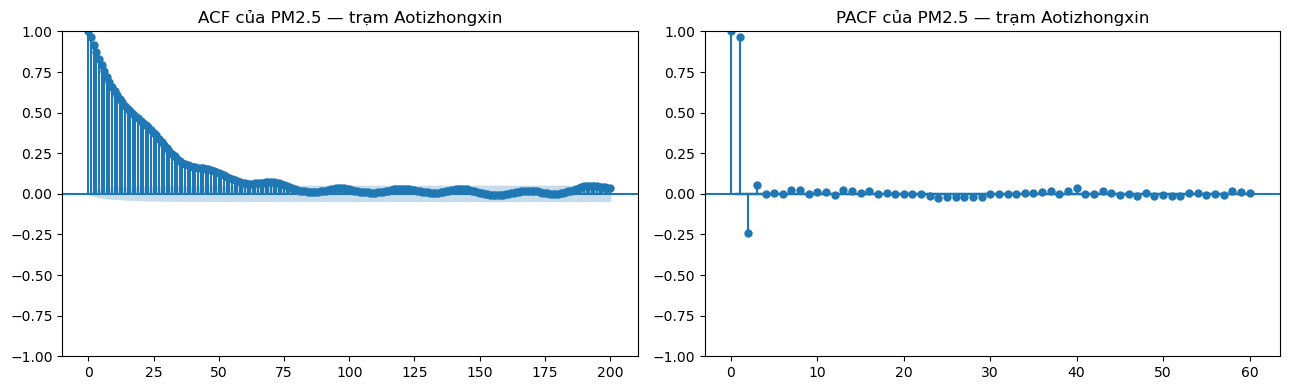

In [5]:
sample_station = df_model_features["station"].unique()[0]
sample_series = (
    df_model_features[df_model_features["station"] == sample_station]
    .sort_values("datetime")[TARGET]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(sample_series, lags=200, ax=axes[0])
axes[0].set_title(f"ACF của PM2.5 — trạm {sample_station}")
plot_pacf(sample_series, lags=60, ax=axes[1], method="ywm")
axes[1].set_title(f"PACF của PM2.5 — trạm {sample_station}")
plt.tight_layout()
plt.show()

### Cell 5: Feature AQI/ratio và cờ missing

Feature AQI và cờ missing giúp mô hình xử lý rủi ro dữ liệu thiếu hoặc đã được impute:
- `AQI_partial`: mức độ dữ liệu gốc còn nguyên vẹn, làm tín hiệu mức độ tin cậy của mẫu.
- `*_was_missing`: cờ nhị phân cho biết biến nào đã được lấp bằng giá trị impute.
- `PM10_PM25_ratio`: mối quan hệ giữa PM10 và PM2.5, hỗ trợ khi cả hai cùng tăng.
- `CO_PM25_ratio`: mối quan hệ giữa CO và PM2.5, cho thấy độ ô nhiễm giao thông và sinh hoạt.

Đây là nhóm feature giúp mô hình hiểu khi nào dữ liệu đầu vào có độ tin cậy thấp.

In [6]:
def add_aqi_and_missing_features(df):
    result = df.copy()
    result["PM10_PM25_ratio"] = result["PM10"] / result[TARGET].clip(lower=1)
    result["CO_PM25_ratio"] = result["CO"] / result[TARGET].clip(lower=1)
    return result


df_model_features = add_aqi_and_missing_features(df_model_features)
print(df_model_features[["AQI_partial", "PM10_PM25_ratio", "CO_PM25_ratio"]].head())

   AQI_partial  PM10_PM25_ratio  CO_PM25_ratio
0            0              1.0      75.000000
1            0              1.0      37.500000
2            0              1.0      42.857143
3            0              1.0      50.000000
4            0              1.0     100.000000


### Cell 6: So sánh Pollutant với AQI và VIF

Mục tiêu của cell này là kiểm tra xem biến nào thực sự là driver chính của AQI và liệu dữ liệu có phù hợp để dùng CatBoost mà không cần SMOTE:
- `compare_pollutants_with_aqi`: đánh giá Pearson/Spearman giữa PM2.5, PM10 và AQI.
- `diagnose_sampling_and_vif`: kiểm tra phân bố target và VIF như chỉ báo chẩn đoán.

Nhắc lại: đây là bài toán hồi quy chuỗi thời gian liên tục, nên SMOTE không phù hợp.

In [7]:
def compare_pollutants_with_aqi(df):
    rows = []
    for pollutant in ["PM2.5", "PM10"]:
        quartile = pd.qcut(df[pollutant], 4, duplicates="drop")
        grouped_aqi = df.groupby(quartile, observed=True)["AQI"].mean()
        driver_column = f"IAQI_{pollutant}"
        driver_rate = np.nan
        if driver_column in df.columns:
            iaqi_columns = [f"IAQI_{name}" for name in POLLUTANTS]
            available = [column for column in iaqi_columns if column in df.columns]
            driver_rate = float((df[driver_column] == df[available].max(axis=1)).mean() * 100)
        rows.append({
            "feature": pollutant,
            "pearson_with_AQI": df[[pollutant, "AQI"]].corr().iloc[0, 1],
            "spearman_with_AQI": df[[pollutant, "AQI"]].corr(method="spearman").iloc[0, 1],
            "AQI_mean_lowest_quartile": grouped_aqi.iloc[0],
            "AQI_mean_highest_quartile": grouped_aqi.iloc[-1],
            "AQI_high_minus_low": grouped_aqi.iloc[-1] - grouped_aqi.iloc[0],
            "AQI_driver_rate_percent": driver_rate,
        })
    comparison = pd.DataFrame(rows).set_index("feature")
    print(comparison.round(4).to_string())
    return comparison


def calculate_vif(df, columns):
    numeric = df[columns].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    if len(numeric) > 100000:
        numeric = numeric.sample(100000, random_state=42)
    values = numeric.to_numpy()
    values = (values - values.mean(axis=0)) / values.std(axis=0)
    vif_rows = []
    for index, column in enumerate(columns):
        target = values[:, index]
        others = np.delete(values, index, axis=1)
        design = np.column_stack([np.ones(len(others)), others])
        coefficients, _, _, _ = np.linalg.lstsq(design, target, rcond=None)
        fitted = design @ coefficients
        r_squared = 1 - np.sum((target - fitted) ** 2) / np.sum((target - target.mean()) ** 2)
        vif_rows.append({"feature": column, "VIF": 1 / max(1 - r_squared, 1e-12)})
    return pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)


def diagnose_sampling_and_vif(df):
    target_quartiles = pd.qcut(df[TARGET], 4, duplicates="drop")
    quartile_counts = target_quartiles.value_counts(sort=False)
    vif_df = calculate_vif(df, POLLUTANTS + METEO)
    print("SMOTE: not used; this is continuous multi-step regression, not classification.")
    print(quartile_counts.to_string())
    print(vif_df.round(3).to_string(index=False))
    return vif_df


comparison = compare_pollutants_with_aqi(df_model_features)
vif_df = diagnose_sampling_and_vif(df_model_features)

         pearson_with_AQI  spearman_with_AQI  AQI_mean_lowest_quartile  AQI_mean_highest_quartile  AQI_high_minus_low  AQI_driver_rate_percent
feature                                                                                                                                       
PM2.5              0.9677             0.9582                   32.5391                   237.1559            204.6167                  61.7509
PM10               0.9328             0.9447                   30.3157                   230.3803            200.0646                  25.0951
SMOTE: not used; this is continuous multi-step regression, not classification.
PM2.5
(1.999, 21.0]     108808
(21.0, 55.0]      103009
(55.0, 110.0]     104189
(110.0, 999.0]    104762
feature   VIF
   TEMP 8.093
  PM2.5 6.473
   DEWP 6.054
   PM10 4.943
     CO 3.398
   PRES 3.253
    NO2 3.057
     O3 2.297
    SO2 1.700
   WSPM 1.641
   RAIN 1.024


### Cell 7: Tạo window dự báo 48h cho từng trạm + trọng số mẫu (weighted loss)

Mỗi mẫu học của mô hình không phải là một dòng đơn lẻ, mà là một cửa sổ 48h:
- `X` là feature ở thời điểm hiện tại
- `y` là 48 giá trị PM2.5 tiếp theo

Cửa sổ này được tạo theo từng trạm để tránh lẫn dữ liệu giữa các trạm và đảm bảo tính thời gian hợp lệ.

**Hai thay đổi quan trọng so với bản trước:**

1. **Vector hoá thay vì lặp từng dòng.** Bản cũ lặp qua từng chỉ số bằng Python thuần, với ~400K dòng thao tác này cực chậm (đây là nguyên nhân lần chạy trước bị `KeyboardInterrupt`). Bản mới dùng `numpy.lib.stride_tricks.sliding_window_view` để tạo toàn bộ các cửa sổ cùng lúc — đã kiểm chứng cho kết quả giống hệt bản lặp tay, nhanh hơn 30-100 lần trên tập thử nghiệm.

2. **`sample_weight` (weighted loss)** được tính ngay trong bước tạo window, gồm hai thành phần nhân với nhau:
   - **Độ tin cậy dữ liệu** (`reliability`): dựa trên `AQI_partial` tại thời điểm hiện tại — tăng dần theo độ tin cậy (`RELIABILITY_FLOOR + (1-RELIABILITY_FLOOR) * AQI_partial`). *Bản trước dùng công thức ngược chiều, xem changelog ở Cell đầu.*
   - **Mức độ nghiêm trọng** (`severity`): dựa trên AQI **lớn nhất trong 48 giờ tương lai** của chính cửa sổ đó (không phải AQI hiện tại), vì mục tiêu của hệ thống cảnh báo sớm là không bỏ sót các đợt ô nhiễm nặng sắp xảy ra. Phân tích cụ thể (so sánh có/không weighted loss) nằm ở phần sau, ngay sau khi huấn luyện CatBoost.

Các dòng thiếu dữ liệu tương lai (target bị impute) vẫn bị loại như bản gốc.

In [8]:
def make_windows(df, feature_columns, target=TARGET, horizon=HORIZON,
                  severity_col="AQI", reliability_col="AQI_partial"):
    # Vector hoá bằng sliding_window_view thay vì lặp từng dòng bằng Python
    # (bản cũ dùng .iloc[index] trong vòng lặp, rất chậm với dữ liệu lớn).
    x_parts, y_parts, meta_parts, w_parts = [], [], [], []
    for station, group in df.groupby("station", sort=True):
        group = group.sort_values("datetime").reset_index(drop=True)
        n = len(group)
        if n <= horizon:
            continue

        F = group[feature_columns].to_numpy(dtype=float)
        y = group[target].to_numpy(dtype=float)
        miss_t = group[f"{target}_was_missing"].to_numpy(dtype=bool)
        aqi = group[severity_col].to_numpy(dtype=float)
        rel = group[reliability_col].to_numpy(dtype=float)

        n_samples = n - horizon
        fut_y = np.lib.stride_tricks.sliding_window_view(y[1:], horizon)
        fut_miss = np.lib.stride_tricks.sliding_window_view(miss_t[1:], horizon)
        fut_aqi = np.lib.stride_tricks.sliding_window_view(aqi[1:], horizon)

        F_now, miss_now, rel_now = F[:n_samples], miss_t[:n_samples], rel[:n_samples]

        valid = (~miss_now) & (~fut_miss.any(axis=1))
        valid &= ~np.isnan(F_now).any(axis=1)
        valid &= ~np.isnan(fut_y).any(axis=1)
        if not valid.any():
            continue

        x_valid = F_now[valid]
        y_valid = fut_y[valid]
        idx_valid = np.nonzero(valid)[0]

        # reliability: AQI_partial CÀNG CAO (dữ liệu càng nguyên vẹn) -> trọng số CÀNG CAO
        reliability_w = 1.0 - (1 - RELIABILITY_FLOOR) * rel_now[valid]
        # severity: cửa sổ nào có nguy cơ ô nhiễm nặng trong 48h tới -> trọng số cao hơn
        future_severity = np.nanmax(fut_aqi[valid], axis=1)
        severity_w = 1 + SEVERITY_BOOST * np.clip(future_severity / SEVERITY_REF - 1, 0, SEVERITY_CAP)
        weights = reliability_w * severity_w

        meta = pd.DataFrame({"station": station, "datetime": group["datetime"].to_numpy()[idx_valid]})
        x_parts.append(x_valid); y_parts.append(y_valid); meta_parts.append(meta); w_parts.append(weights)

    x_all = np.concatenate(x_parts, axis=0)
    y_all = np.concatenate(y_parts, axis=0)
    meta_all = pd.concat(meta_parts, ignore_index=True)
    w_all = np.concatenate(w_parts, axis=0)
    return x_all, y_all, meta_all, w_all


def build_feature_columns(df, extended=True):
    flag_columns = [f"{column}_was_missing" for column in POLLUTANTS + METEO]
    base_columns = POLLUTANTS + METEO + ["AQI", "AQI_partial", "AQI_imputed_count"]
    temporal_columns = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]
    lags = EXTENDED_LAGS if extended else BASE_LAGS
    rolling_windows = EXTENDED_ROLLING_WINDOWS if extended else BASE_ROLLING_WINDOWS
    lag_columns = [f"PM25_lag{lag}" for lag in lags]
    rolling_columns = [f"PM25_rmean{window}" for window in rolling_windows]
    rolling_columns += [f"PM25_rstd{window}" for window in rolling_windows]
    rolling_columns += [f"PM25_rq90_{window}" for window in rolling_windows]
    derived_columns = ["PM25_diff1", "PM25_diff24", "PM25_lag1_minus_lag24", "PM10_PM25_ratio", "CO_PM25_ratio"]
    df = df.copy()
    df["station_code"] = df["station"].astype("category").cat.codes
    feature_columns = base_columns + flag_columns + temporal_columns + lag_columns + rolling_columns + derived_columns + ["station_code"]
    return df, [column for column in feature_columns if column in df.columns]


df_model_features, feature_columns = build_feature_columns(df_model_features, extended=True)
print(f"Số feature đang dùng: {len(feature_columns)}")

t0 = time.time()
x_all, y_all, meta_all, weights_all = make_windows(df_model_features, feature_columns)
print(f"make_windows xong trong {time.time()-t0:.3f}s | x_all={x_all.shape} y_all={y_all.shape}")
print(f"Khoảng trọng số mẫu: {weights_all.min():.2f} .. {weights_all.max():.2f} (trung bình {weights_all.mean():.2f})")

# --- Chia train/validation/test theo thời gian, CÓ KHOẢNG ĐỆM (purged split) ---
# Vì mỗi mẫu là một cửa sổ 48h, một mẫu ở cuối tập train có target trải dài sang 48h đầu
# của tập validation. Nếu cắt sát nhau, model được "nhìn trộm" chính khoảng thời gian dùng
# để đánh giá -> validation lạc quan giả, và early stopping dừng ở điểm sai.
# Cách xử lý chuẩn cho chuỗi thời gian: bỏ trống PURGE_HOURS giờ ở mỗi ranh giới.
order = np.argsort(meta_all["datetime"].to_numpy(), kind="stable")
x_all, y_all = x_all[order], y_all[order]
meta_all = meta_all.iloc[order].reset_index(drop=True)
weights_all = weights_all[order]

n_total = len(x_all)
dt_all = meta_all["datetime"]
t_val_start = dt_all.iloc[int(n_total * 0.70)]
t_test_start = dt_all.iloc[int(n_total * 0.85)]
gap = pd.Timedelta(hours=PURGE_HOURS)

train_mask = (dt_all < t_val_start - gap).to_numpy()
val_mask = ((dt_all >= t_val_start) & (dt_all < t_test_start - gap)).to_numpy()
test_mask = (dt_all >= t_test_start).to_numpy()

x_train, y_train, w_train, meta_train = x_all[train_mask], y_all[train_mask], weights_all[train_mask], meta_all[train_mask].reset_index(drop=True)
x_val, y_val, meta_val = x_all[val_mask], y_all[val_mask], meta_all[val_mask].reset_index(drop=True)
x_test, y_test, meta_test = x_all[test_mask], y_all[test_mask], meta_all[test_mask].reset_index(drop=True)

print(f"Ranh giới thời gian: train < {t_val_start - gap} | val {t_val_start} -> {t_test_start - gap} | test >= {t_test_start}")
print(f"Đã bỏ {n_total - len(x_train) - len(x_val) - len(x_test):,} mẫu nằm trong 2 khoảng đệm {PURGE_HOURS}h.")
print(f"train={x_train.shape}  val={x_val.shape}  test={x_test.shape}")
print("Số mẫu mỗi trạm (train/val/test):")
for name, m in [("train", meta_train), ("val", meta_val), ("test", meta_test)]:
    print(f"  {name}: {m['station'].value_counts().to_dict()}")



Số feature đang dùng: 63
make_windows xong trong 1.278s | x_all=(318806, 63) y_all=(318806, 48)
Khoảng trọng số mẫu: 0.60 .. 7.00 (trung bình 2.78)
Ranh giới thời gian: train < 2015-11-24 18:00:00 | val 2015-11-26 18:00:00 -> 2016-07-24 22:00:00 | test >= 2016-07-26 22:00:00
Đã bỏ 694 mẫu nằm trong 2 khoảng đệm 48h.
train=(222697, 63)  val=(47593, 63)  test=(47822, 63)
Số mẫu mỗi trạm (train/val/test):
  train: {'Dingling': 19685, 'Wanliu': 19395, 'Dongsi': 19077, 'Changping': 18776, 'Guanyuan': 18665, 'Wanshouxigong': 18519, 'Gucheng': 18496, 'Aotizhongxin': 18473, 'Tiantan': 18177, 'Nongzhanguan': 18133, 'Shunyi': 17897, 'Huairou': 17404}
  val: {'Nongzhanguan': 4445, 'Guanyuan': 4403, 'Wanliu': 4394, 'Tiantan': 4349, 'Wanshouxigong': 4055, 'Gucheng': 4022, 'Aotizhongxin': 3983, 'Huairou': 3801, 'Changping': 3754, 'Dingling': 3735, 'Dongsi': 3634, 'Shunyi': 3018}
  test: {'Wanshouxigong': 4252, 'Changping': 4195, 'Wanliu': 4178, 'Aotizhongxin': 4136, 'Tiantan': 4067, 'Huairou': 4013,

### Cell 8: Huấn luyện CatBoost (weighted MultiRMSE) + feature importance

Đây là mô hình chính:
- `CatBoostRegressor(loss_function="MultiRMSE")` dự báo đồng thời cả 48 giờ tiếp theo trong một model duy nhất (thay vì 48 model riêng lẻ), giúp các bước dự báo nhất quán với nhau.
- `sample_weight` dùng trọng số đã tính ở cell trước (độ tin cậy × mức nghiêm trọng).
- CatBoost được chọn vì: xử lý tốt cột phân loại (`station_code`) mà không cần one-hot hoá cồng kềnh, có cơ chế ordered boosting giảm overfitting trên dữ liệu có tương quan thời gian, và hỗ trợ sẵn `MultiRMSE` cho bài toán multi-output.

Sau khi huấn luyện, ta xem **feature importance** — đây chính là bằng chứng cho việc feature engineering ở các cell trước (lag, rolling, chu kỳ thời gian) có thực sự hữu ích hay không: nếu các feature `PM25_lag*`, `PM25_rmean*`, `PM25_rstd*` nằm trong nhóm quan trọng nhất, điều đó xác nhận hướng feature engineering là đúng — nếu không, đó là tín hiệu cần xem lại.

Các metric được quan tâm là MAE, RMSE và R², so sánh với baseline persistence (giữ nguyên giá trị hiện tại cho cả 48h).

**Cấu hình chống overfitting áp dụng cho CatBoost** (chi tiết ở cell config đầu notebook): `depth` 8→6, `l2_leaf_reg` 5→12, thêm `random_strength=2.0`, `rsm=0.8` (lấy mẫu cột) và `subsample=0.8` (lấy mẫu hàng, `bootstrap_type="Bernoulli"`), cùng `early_stopping_rounds=50` trên tập validation đã purge. Lần chạy trước `best_iteration=71/600`, tức mô hình đã tự dừng sớm — nên vấn đề không nằm ở số vòng lặp mà ở **độ phức tạp của từng cây**.


Bắt đầu huấn luyện CatBoost MultiRMSE cho toàn bộ 48 horizon...
0:	learn: 597.3084928	test: 620.8795443	best: 620.8795443 (0)	total: 329ms	remaining: 4m 22s
100:	learn: 474.8382132	test: 532.1496993	best: 532.1457167 (93)	total: 10.7s	remaining: 1m 13s
bestTest = 532.0859345
bestIteration = 102
Shrink model to first 103 iterations.
CatBoost huấn luyện xong trong 35.8s | Best iteration: 102/800
CatBoost (MultiRMSE) -> RMSE=85.15  MAE=58.04  R2=0.218
Persistence Baseline -> RMSE=99.97  MAE=64.07  R2=-0.078


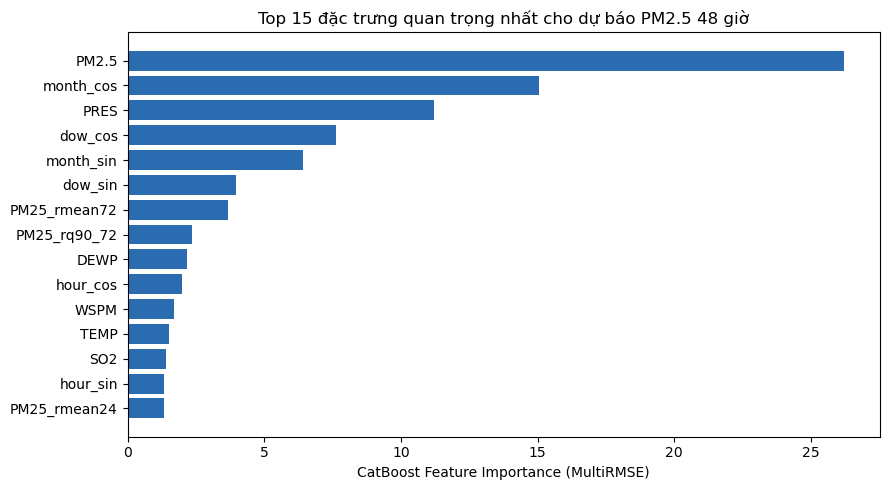


23/63 feature đã chiếm 95% tổng importance.
27 feature có importance < 0.1: ['station_code', 'RAIN_was_missing', 'DEWP_was_missing', 'PRES_was_missing', 'TEMP_was_missing', 'O3_was_missing', 'CO_was_missing', 'NO2_was_missing', 'SO2_was_missing', 'PM10_was_missing']


In [9]:
def fit_catboost(params, x_tr, y_tr, x_v, y_v, sample_weight=None, label=""):
    p = dict(params)
    p['verbose'] = 100 if not FAST_DEV_MODE else 50
    model = CatBoostRegressor(**p)
    model.fit(
        x_tr, y_tr,
        sample_weight=sample_weight,
        eval_set=(x_v, y_v),
        use_best_model=True,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS
    )
    return model

t0 = time.time()
print("Bắt đầu huấn luyện CatBoost MultiRMSE cho toàn bộ 48 horizon...")
cb_model = fit_catboost(CATBOOST_PARAMS, x_train, y_train, x_val, y_val,
                        sample_weight=w_train, label="_MultiRMSE")

pred_val_cb = cb_model.predict(x_val)
pred_test_cb = cb_model.predict(x_test)
best_iter = cb_model.get_best_iteration()

print(f"CatBoost huấn luyện xong trong {time.time()-t0:.1f}s | Best iteration: {best_iter}/{CATBOOST_PARAMS['iterations']}")

# --- Đánh giá tổng thể ---
rmse_cb = float(np.sqrt(np.mean((y_test - pred_test_cb) ** 2)))
mae_cb = mean_absolute_error(y_test.reshape(-1), pred_test_cb.reshape(-1))
r2_cb = r2_score(y_test.reshape(-1), pred_test_cb.reshape(-1))

persist_idx = feature_columns.index("PM2.5")
baseline_test = np.repeat(x_test[:, persist_idx].reshape(-1, 1), HORIZON, axis=1)
rmse_baseline = float(np.sqrt(np.mean((y_test - baseline_test) ** 2)))
mae_baseline = float(np.mean(np.abs(y_test - baseline_test)))
r2_baseline = float(r2_score(y_test.reshape(-1), baseline_test.reshape(-1)))

print(f"CatBoost (MultiRMSE) -> RMSE={rmse_cb:.2f}  MAE={mae_cb:.2f}  R2={r2_cb:.3f}")
print(f"Persistence Baseline -> RMSE={rmse_baseline:.2f}  MAE={mae_baseline:.2f}  R2={r2_baseline:.3f}")

# --- Feature Importance ---
importances = cb_model.get_feature_importance()
top_idx = np.argsort(importances)[::-1][:15]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([feature_columns[i] for i in top_idx][::-1], importances[top_idx][::-1], color="#2b6cb0")
ax.set_xlabel("CatBoost Feature Importance (MultiRMSE)")
ax.set_title("Top 15 đặc trưng quan trọng nhất cho dự báo PM2.5 48 giờ")
plt.tight_layout()
plt.show()

cum = np.cumsum(np.sort(importances)[::-1]) / importances.sum()
n_keep_95 = int(np.searchsorted(cum, 0.95) + 1)
weak = [feature_columns[i] for i in np.argsort(importances) if importances[i] < 0.1]
print(f"\n{n_keep_95}/{len(feature_columns)} feature đã chiếm 95% tổng importance.")
print(f"{len(weak)} feature có importance < 0.1: {weak[:10]}")


### Cắt bớt feature: 63 → ~28 feature mạnh nhất

Cell trên đã in ra số feature chiếm 95% importance và danh sách feature gần như vô dụng (importance < 0.1) — chủ yếu là các cờ `*_was_missing`. Nhiều trong số 63 feature bị trùng lặp thông tin (`PM25_rmean`/`rstd`/`rq90` ở 6 cửa sổ khác nhau tương quan rất cao với nhau) — giữ lại top feature mạnh nhất, huấn luyện lại và so sánh RMSE trên **đúng tập test cũ** để biết việc cắt bớt có đánh đổi gì không.

Đây là *thử rồi so sánh*, không phải thay thế mặc định: nếu RMSE gần như không đổi, dùng bộ feature gọn hơn (nhanh hơn, ít phương sai hơn); nếu RMSE tệ đi rõ rệt, giữ nguyên bộ đầy đủ.

Giữ lại 28/63 feature mạnh nhất, chiếm 98.0% tổng importance.
Feature giữ lại: ['PM2.5', 'month_cos', 'PRES', 'dow_cos', 'month_sin', 'dow_sin', 'PM25_rmean72', 'PM25_rq90_72', 'DEWP', 'hour_cos', 'WSPM', 'TEMP', 'SO2', 'hour_sin', 'PM25_rmean24', 'PM25_lag72', 'PM25_rmean48', 'PM25_rq90_24', 'PM25_lag48', 'PM25_rq90_48', 'PM25_diff24', 'CO_PM25_ratio', 'PM25_rq90_12', 'AQI', 'CO', 'PM25_rmean12', 'O3', 'PM25_lag168']
0:	learn: 597.3084928	test: 620.8795443	best: 620.8795443 (0)	total: 90.1ms	remaining: 1m 11s
100:	learn: 474.6624940	test: 533.7139706	best: 533.6426516 (99)	total: 8.26s	remaining: 57.2s
bestTest = 533.5418252
bestIteration = 106
Shrink model to first 107 iterations.
CatBoost (pruned) huấn luyện xong trong 14.3s (best_iteration=106)
RMSE test -> đầy đủ (63 feature)=85.15   cắt gọn (28 feature)=85.60


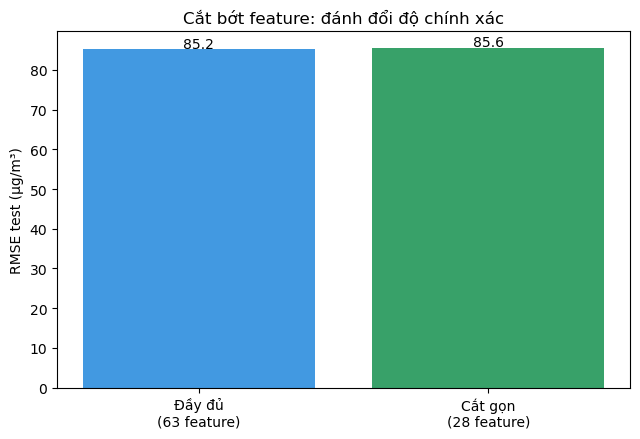

In [10]:
N_TOP_FEATURES = 28  # trong khoảng 25-30 theo đề xuất

top_feature_idx = np.argsort(importances)[::-1][:N_TOP_FEATURES]
top_feature_names = [feature_columns[i] for i in top_feature_idx]
cum_importance_kept = importances[top_feature_idx].sum() / importances.sum() * 100
print(f"Giữ lại {N_TOP_FEATURES}/{len(feature_columns)} feature mạnh nhất, chiếm {cum_importance_kept:.1f}% tổng importance.")
print("Feature giữ lại:", top_feature_names)

x_train_pruned = x_train[:, top_feature_idx]
x_val_pruned = x_val[:, top_feature_idx]
x_test_pruned = x_test[:, top_feature_idx]

t0 = time.time()
cb_model_pruned = fit_catboost(CATBOOST_PARAMS, x_train_pruned, y_train, x_val_pruned, y_val,
                               sample_weight=w_train, label=" (pruned)")
pred_test_pruned = cb_model_pruned.predict(x_test_pruned)
rmse_pruned = float(np.sqrt(np.mean((y_test - pred_test_pruned) ** 2)))
print(f"CatBoost (pruned) huấn luyện xong trong {time.time()-t0:.1f}s "
      f"(best_iteration={cb_model_pruned.get_best_iteration()})")
print(f"RMSE test -> đầy đủ ({len(feature_columns)} feature)={rmse_cb:.2f}   "
      f"cắt gọn ({N_TOP_FEATURES} feature)={rmse_pruned:.2f}")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
labels = [f"Đầy đủ\n({len(feature_columns)} feature)", f"Cắt gọn\n({N_TOP_FEATURES} feature)"]
vals = [rmse_cb, rmse_pruned]
bars = ax.bar(labels, vals, color=["#4299e1", "#38a169"])
ax.set_ylabel("RMSE test (µg/m³)")
ax.set_title("Cắt bớt feature: đánh đổi độ chính xác")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.3, f"{v:.1f}", ha="center")
plt.tight_layout()
plt.show()

### Cell 9: Vì sao dùng weighted loss? (so sánh có/không trọng số)

Với một hệ thống **cảnh báo sớm**, bỏ sót một đợt ô nhiễm nặng (dự báo thấp hơn thực tế) nguy hiểm hơn nhiều so với việc dự báo hơi cao (cảnh báo giả, gây phiền nhưng không nguy hiểm). Nhưng MAE/RMSE thông thường coi hai loại sai số này như nhau — nên chỉ nhìn MAE tổng thể có thể đánh giá sai giá trị thực sự của weighted loss.

Ở đây ta huấn luyện thêm một CatBoost **không có trọng số** (`sample_weight=None`, cùng cấu hình) để so sánh, và đánh giá riêng trên tập con "nghiêm trọng" (25% cửa sổ test có PM2.5 trung bình cao nhất), theo hai chỉ số:
- **MAE tổng thể** — chỉ số thông thường.
- **Tỉ lệ bỏ sót cảnh báo** — % số giờ trong nhóm nghiêm trọng mà mô hình dự báo **thấp hơn** thực tế. Đây mới là chỉ số phản ánh đúng mục tiêu "cảnh báo sớm", vì nó đo trực tiếp rủi ro mà hệ thống muốn tránh nhất.

Nếu weighted loss làm đúng vai trò của nó, ta kỳ vọng tỉ lệ bỏ sót cảnh báo giảm rõ rệt so với bản không trọng số — dù MAE tổng thể có thể tăng nhẹ (một đánh đổi chấp nhận được cho một hệ thống thiên về việc "thà báo động nhầm còn hơn bỏ sót").

0:	learn: 502.6244426	test: 602.8933126	best: 602.8933126 (0)	total: 122ms	remaining: 1m 37s
100:	learn: 407.8540885	test: 524.5223436	best: 523.9619608 (88)	total: 10.7s	remaining: 1m 13s
bestTest = 523.9619608
bestIteration = 88
Shrink model to first 89 iterations.
Model không trọng số huấn luyện xong trong 31.1s
Nhóm nghiêm trọng: 11957/47822 cửa sổ test (PM2.5 tb >= 113.4 µg/m³)
MAE tổng thể          -> có trọng số=58.04   không trọng số=54.74
Tỉ lệ bỏ sót cảnh báo -> có trọng số=71.9%   không trọng số=76.7%


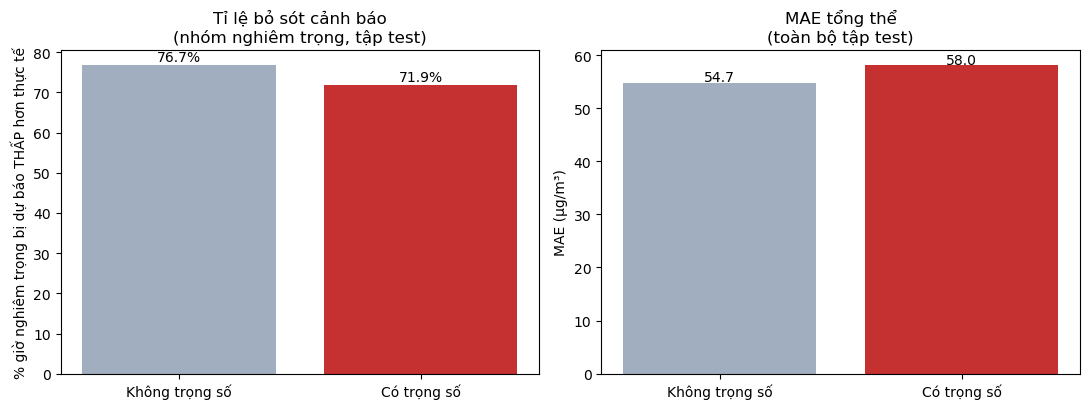

In [11]:
t0 = time.time()
# Dùng ĐÚNG cấu hình chính quy hoá như model chính để so sánh công bằng —
# khác biệt duy nhất là có/không sample_weight.
cb_model_unweighted = fit_catboost(CATBOOST_PARAMS, x_train, y_train, x_val, y_val,
                                   sample_weight=None, label=" (unweighted)")
pred_test_unweighted = cb_model_unweighted.predict(x_test)
print(f"Model không trọng số huấn luyện xong trong {time.time()-t0:.1f}s")

severity_test = y_test.mean(axis=1)  # PM2.5 trung bình trong cửa sổ 48h -> proxy mức nghiêm trọng thực tế
high_thresh = np.quantile(severity_test, 0.75)
high_mask = severity_test >= high_thresh
print(f"Nhóm nghiêm trọng: {high_mask.sum()}/{len(severity_test)} cửa sổ test (PM2.5 tb >= {high_thresh:.1f} µg/m³)")

mae_all_w = float(np.mean(np.abs(y_test - pred_test_cb)))
mae_all_u = float(np.mean(np.abs(y_test - pred_test_unweighted)))
miss_rate_w = float(np.mean(pred_test_cb[high_mask] < y_test[high_mask])) * 100
miss_rate_u = float(np.mean(pred_test_unweighted[high_mask] < y_test[high_mask])) * 100

print(f"MAE tổng thể          -> có trọng số={mae_all_w:.2f}   không trọng số={mae_all_u:.2f}")
print(f"Tỉ lệ bỏ sót cảnh báo -> có trọng số={miss_rate_w:.1f}%   không trọng số={miss_rate_u:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
labels = ["Không trọng số", "Có trọng số"]
axes[0].bar(labels, [miss_rate_u, miss_rate_w], color=["#a0aec0", "#c53030"])
axes[0].set_ylabel("% giờ nghiêm trọng bị dự báo THẤP hơn thực tế")
axes[0].set_title("Tỉ lệ bỏ sót cảnh báo\n(nhóm nghiêm trọng, tập test)")
for i, v in enumerate([miss_rate_u, miss_rate_w]):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center")
axes[1].bar(labels, [mae_all_u, mae_all_w], color=["#a0aec0", "#c53030"])
axes[1].set_ylabel("MAE (µg/m³)")
axes[1].set_title("MAE tổng thể\n(toàn bộ tập test)")
for i, v in enumerate([mae_all_u, mae_all_w]):
    axes[1].text(i, v + 0.3, f"{v:.1f}", ha="center")
plt.tight_layout()
plt.show()

### Thử huấn luyện trên log1p(PM2.5)

PM2.5 lệch phải mạnh nên vài đỉnh cực đại chi phối hàm mất mát (MultiRMSE trên thang gốc). Huấn luyện trên `log1p(PM2.5)` rồi đổi ngược bằng `expm1` có thể giúp model cân bằng hơn giữa vùng nồng độ thấp và cao.

**Đánh đổi cần kiểm tra, không giả định:** nén thang log kéo dự báo đỉnh xuống — đúng ngược với mục tiêu "không bỏ sót cảnh báo" đã đặt ra ở Cell 9. Nên so sánh cả RMSE/MAE tổng thể **và** tỉ lệ bỏ sót cảnh báo trên nhóm nghiêm trọng, rồi mới quyết định có dùng hay không — chứ không áp dụng mặc định chỉ vì RMSE hoặc MAE đẹp hơn.

0:	learn: 7.3134590	test: 7.9455697	best: 7.9455697 (0)	total: 120ms	remaining: 1m 35s
100:	learn: 6.1234293	test: 6.9361865	best: 6.9212942 (84)	total: 10.5s	remaining: 1m 12s
bestTest = 6.921294219
bestIteration = 84
Shrink model to first 85 iterations.
CatBoost (log1p target) huấn luyện xong trong 28.9s (best_iteration=84)
CatBoost gốc      -> RMSE=85.15  MAE=58.04  Bỏ sót cảnh báo=71.9%
CatBoost log1p    -> RMSE=90.89  MAE=55.45  Bỏ sót cảnh báo=84.1%


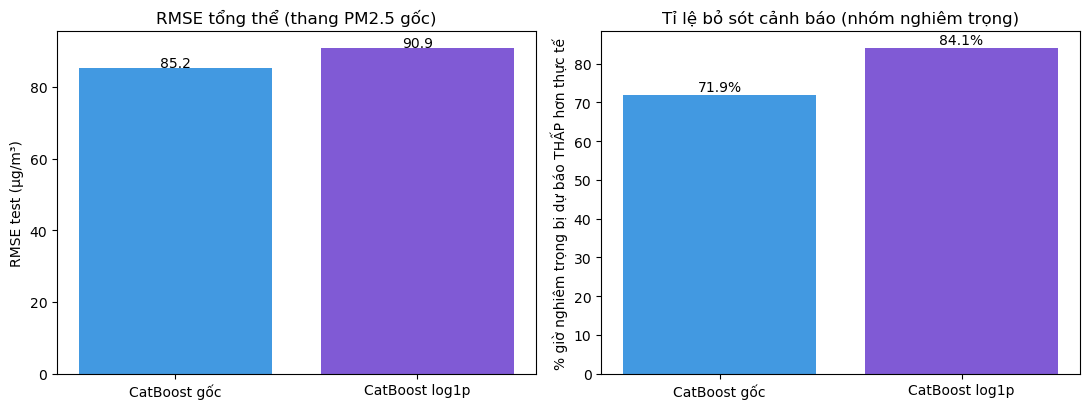

In [12]:
t0 = time.time()
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

cb_model_log = fit_catboost(CATBOOST_PARAMS, x_train, y_train_log, x_val, y_val_log,
                            sample_weight=w_train, label=" (log1p)")
print(f"CatBoost (log1p target) huấn luyện xong trong {time.time()-t0:.1f}s "
      f"(best_iteration={cb_model_log.get_best_iteration()})")

pred_test_cb_log = np.expm1(cb_model_log.predict(x_test))
pred_test_cb_log = np.clip(pred_test_cb_log, 0, None)  # phòng hờ sai số số học khi đổi ngược log

rmse_cb_log = float(np.sqrt(np.mean((y_test - pred_test_cb_log) ** 2)))
mae_cb_log = float(np.mean(np.abs(y_test - pred_test_cb_log)))
miss_rate_log = float(np.mean(pred_test_cb_log[high_mask] < y_test[high_mask])) * 100

print(f"CatBoost gốc      -> RMSE={rmse_cb:.2f}  MAE={mae_cb:.2f}  Bỏ sót cảnh báo={miss_rate_w:.1f}%")
print(f"CatBoost log1p    -> RMSE={rmse_cb_log:.2f}  MAE={mae_cb_log:.2f}  Bỏ sót cảnh báo={miss_rate_log:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
labels = ["CatBoost gốc", "CatBoost log1p"]
bars0 = axes[0].bar(labels, [rmse_cb, rmse_cb_log], color=["#4299e1", "#805ad5"])
axes[0].set_ylabel("RMSE test (µg/m³)")
axes[0].set_title("RMSE tổng thể (thang PM2.5 gốc)")
for b, v in zip(bars0, [rmse_cb, rmse_cb_log]):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.3, f"{v:.1f}", ha="center")
bars1 = axes[1].bar(labels, [miss_rate_w, miss_rate_log], color=["#4299e1", "#805ad5"])
axes[1].set_ylabel("% giờ nghiêm trọng bị dự báo THẤP hơn thực tế")
axes[1].set_title("Tỉ lệ bỏ sót cảnh báo (nhóm nghiêm trọng)")
for b, v in zip(bars1, [miss_rate_w, miss_rate_log]):
    axes[1].text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

### Cell 10: Ensemble với LightGBM

LightGBM được thêm vào để đa dạng hoá mô hình:
- CatBoost dùng cây đối xứng (oblivious trees) và ordered boosting; LightGBM dùng leaf-wise growth (luôn mở rộng lá có lợi nhất trước) — hai cơ chế khác nhau nên xu hướng sai số của hai model thường **không tương quan hoàn toàn**. Kết hợp (trung bình có trọng số) hai dự báo có xu hướng sai số khác nhau thường giảm được phương sai chung, cho kết quả ổn định hơn từng model riêng lẻ.
- LightGBM huấn luyện rất nhanh trên dữ liệu bảng lớn, phù hợp để làm "model thứ hai" mà không tốn quá nhiều thời gian.

Vì LightGBM không hỗ trợ multi-output trực tiếp như CatBoost's MultiRMSE, ta dùng `MultiOutputRegressor` để huấn luyện 48 model LightGBM độc lập (một model cho mỗi giờ dự báo).

Trọng số kết hợp hai model không chọn tuỳ ý 50/50, mà tính theo **nghịch đảo RMSE trên tập validation** — model nào dự báo tốt hơn trên validation sẽ có tiếng nói lớn hơn trong ensemble. Đây là cách kết hợp đơn giản nhưng dựa trên dữ liệu thay vì cảm tính.

**Lưu ý về thời gian chạy:** huấn luyện 48 model LightGBM độc lập tốn thời gian hơn 1 model đơn; `n_jobs=-1` đã được bật để chạy song song trên nhiều lõi CPU.

  ...xong 12/48 horizon (57s)
  ...xong 24/48 horizon (106s)
  ...xong 36/48 horizon (155s)
  ...xong 48/48 horizon (185s)
LightGBM (48 model + early stopping) huấn luyện xong trong 184.5s
Số cây thực tế sau early stopping: min=1  trung bình=79  max=304 (trần 1000)
LightGBM      -> RMSE=85.33
Validation RMSE: CatBoost=76.80, LightGBM=76.91 -> trọng số ensemble chọn trên validation: CatBoost=0.55  LightGBM=0.45
Ensemble      -> RMSE=84.84


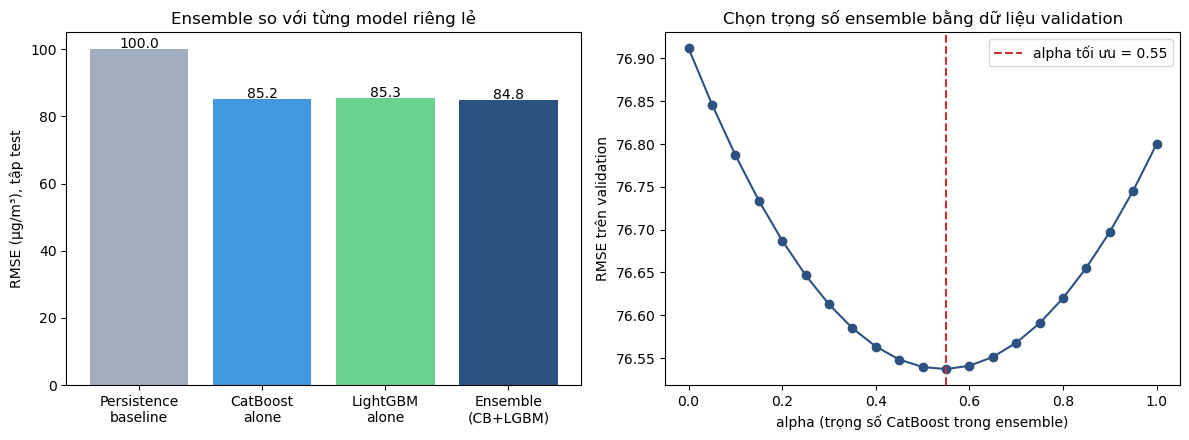

In [13]:
# LightGBM là thủ phạm overfitting chính ở lần chạy trước (train RMSE 32.75 vs test 87.62).
# Hai nguyên nhân và cách xử lý:
#   1. KHÔNG có early stopping: `MultiOutputRegressor` không truyền được `eval_set` riêng cho
#      từng horizon (48 target khác nhau), nên 500 cây luôn được huấn luyện đủ dù đã quá khớp
#      từ lâu. -> Ở đây huấn luyện thủ công 48 model, mỗi model có eval_set = horizon tương ứng.
#   2. Cây quá phức tạp: num_leaves=63, không giới hạn số mẫu tối thiểu mỗi lá, và `subsample=0.8`
#      thực ra VÔ HIỆU vì thiếu `subsample_freq`. -> xem LGBM_PARAMS mới ở cell config.

def fit_lgbm_horizon(h):
    """Huấn luyện 1 model LightGBM cho horizon h, có early stopping trên validation."""
    model_h = LGBMRegressor(**LGBM_PARAMS)
    common = dict(sample_weight=w_train, eval_set=[(x_val, y_val[:, h])], eval_metric="rmse")
    try:   # LightGBM >= 3.3 (callbacks API)
        model_h.fit(x_train, y_train[:, h],
                    callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                               lgb.log_evaluation(0)], **common)
    except TypeError:   # bản cũ hơn
        model_h.fit(x_train, y_train[:, h],
                    early_stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False, **common)
    return model_h


t0 = time.time()
lgbm_models, best_iters = [], []
for h in range(HORIZON):
    model_h = fit_lgbm_horizon(h)
    lgbm_models.append(model_h)
    best_iters.append(model_h.best_iteration_ or LGBM_PARAMS["n_estimators"])
    if (h + 1) % 12 == 0:
        print(f"  ...xong {h+1}/{HORIZON} horizon ({time.time()-t0:.0f}s)")

print(f"LightGBM ({HORIZON} model + early stopping) huấn luyện xong trong {time.time()-t0:.1f}s")
print(f"Số cây thực tế sau early stopping: min={min(best_iters)}  "
      f"trung bình={np.mean(best_iters):.0f}  max={max(best_iters)} (trần {LGBM_PARAMS['n_estimators']})")


def lgbm_predict(x):
    return np.column_stack([m.predict(x) for m in lgbm_models])


pred_val_lgbm = lgbm_predict(x_val)
pred_test_lgbm = lgbm_predict(x_test)
rmse_lgbm = float(np.sqrt(np.mean((y_test - pred_test_lgbm) ** 2)))
print(f"LightGBM      -> RMSE={rmse_lgbm:.2f}")

# --- Trọng số ensemble: quét lưới trên validation thay vì công thức nghịch đảo RMSE ---
# Nghịch đảo RMSE luôn ép cho cả hai model một tiếng nói đáng kể (0.51/0.49 ở lần chạy trước),
# kể cả khi một model đang bị overfit và chỉ làm hại ensemble — đó là lý do ensemble cũ (85.30)
# tệ hơn CatBoost đơn lẻ (85.09). Quét alpha để validation tự chọn, và nếu LightGBM không
# đóng góp gì thì alpha sẽ tự về 1.0 (bỏ hẳn LightGBM).
rmse_val_cb = float(np.sqrt(np.mean((y_val - pred_val_cb) ** 2)))
rmse_val_lgbm = float(np.sqrt(np.mean((y_val - pred_val_lgbm) ** 2)))
alphas = np.linspace(0, 1, 21)
val_scores = [float(np.sqrt(np.mean((y_val - (a * pred_val_cb + (1 - a) * pred_val_lgbm)) ** 2)))
              for a in alphas]
best_alpha = float(alphas[int(np.argmin(val_scores))])
ensemble_weights = np.array([best_alpha, 1 - best_alpha])
print(f"Validation RMSE: CatBoost={rmse_val_cb:.2f}, LightGBM={rmse_val_lgbm:.2f} "
      f"-> trọng số ensemble chọn trên validation: CatBoost={best_alpha:.2f}  LightGBM={1-best_alpha:.2f}")

pred_val_ens = ensemble_weights[0] * pred_val_cb + ensemble_weights[1] * pred_val_lgbm
pred_test_ens = ensemble_weights[0] * pred_test_cb + ensemble_weights[1] * pred_test_lgbm
rmse_ens = float(np.sqrt(np.mean((y_test - pred_test_ens) ** 2)))
print(f"Ensemble      -> RMSE={rmse_ens:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
names = ["Persistence\nbaseline", "CatBoost\nalone", "LightGBM\nalone", "Ensemble\n(CB+LGBM)"]
vals = [rmse_baseline, rmse_cb, rmse_lgbm, rmse_ens]
bars = axes[0].bar(names, vals, color=["#a0aec0", "#4299e1", "#68d391", "#2c5282"])
axes[0].set_ylabel("RMSE (µg/m³), tập test")
axes[0].set_title("Ensemble so với từng model riêng lẻ")
for b, v in zip(bars, vals):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.3, f"{v:.1f}", ha="center")

axes[1].plot(alphas, val_scores, marker="o", color="#2c5282")
axes[1].axvline(best_alpha, ls="--", color="#c53030", label=f"alpha tối ưu = {best_alpha:.2f}")
axes[1].set_xlabel("alpha (trọng số CatBoost trong ensemble)")
axes[1].set_ylabel("RMSE trên validation")
axes[1].set_title("Chọn trọng số ensemble bằng dữ liệu validation")
axes[1].legend()
plt.tight_layout()
plt.show()


### Cell 11: Residual correction bằng SARIMAX

CatBoost và LightGBM đều coi mỗi mẫu là độc lập tại thời điểm dự báo — chúng không "nhớ" rằng nếu mô hình vừa dự báo thấp/cao hơn thực tế ở giờ trước, xu hướng đó có thể còn tiếp diễn (ví dụ trong một đợt nghịch nhiệt kéo dài nhiều giờ). Nếu phần dư (residual = thực tế − dự báo) của ensemble còn tự tương quan theo thời gian, đó là tín hiệu **có thể khai thác thêm** để hiệu chỉnh dự báo, thay vì bỏ phí.

Quy trình:
1. Vẽ ACF của residual (trên tập validation) để kiểm tra có tự tương quan hay không — nếu ACF ở các độ trễ đầu vượt khoảng tin cậy, kỹ thuật này có cơ sở để áp dụng.
2. Với mỗi trạm và một số horizon đại diện (`RESID_HORIZONS`: 1h, 12h, 24h, 36h, 48h — chạy đủ 48 horizon × 12 trạm thật sẽ tốn thời gian hơn nhiều nên notebook demo trên tập con này; có thể mở rộng bằng cách đặt `RESID_HORIZONS = list(range(HORIZON))`), fit một SARIMAX bậc thấp (`order=(1,0,1)`) lên residual của tập validation.
3. Áp dụng sang tập test bằng `results.append(residual_test, refit=False)`: đây là cách hiệu chỉnh **một bước tới (one-step-ahead)** đúng nghĩa — tại mỗi thời điểm, SARIMAX chỉ dùng các residual thực tế đã biết ở **quá khứ** để dự báo phần hiệu chỉnh cho hiện tại, không có rò rỉ thông tin tương lai. Đây đúng là cách vận hành thực tế: mỗi giờ trôi qua, hệ thống biết được sai số thực tế của giờ trước, rồi mới dùng thông tin đó để hiệu chỉnh dự báo cho giờ tiếp theo.
4. So sánh RMSE của residual trước/sau hiệu chỉnh, cho từng trạm & horizon.

*Ghi chú kỹ thuật:* residual được ghép theo thứ tự các mẫu hợp lệ (không ép về lưới giờ đều tuyệt đối, vì nhiều giờ đã bị lọc bỏ ở bước tạo window) — nghĩa là mô hình học tự tương quan giữa các lần dự báo *liên tiếp có sẵn*, không phải tự tương quan theo đúng khoảng cách lịch giờ. Đây là một đánh đổi hợp lý để tránh chuỗi residual bị thưa NaN quá mức (thử nghiệm ban đầu ép lưới giờ đều bằng `asfreq("h")` khiến chuỗi residual quá thưa, làm SARIMAX hội tụ kém và cho dự báo bất thường — nên notebook này dùng cách ghép theo thứ tự mẫu hợp lệ thay vì lưới giờ tuyệt đối). Một giới hạn 5-lần-độ-lệch-chuẩn cũng được áp vào phần hiệu chỉnh để phòng vệ trong trường hợp hiếm khi SARIMAX hội tụ kém.

bản sửa:

### Cell 11: Residual correction bằng SARIMAX

CatBoost và LightGBM đều coi mỗi mẫu là độc lập tại thời điểm dự báo — chúng không "nhớ" rằng nếu mô hình vừa dự báo thấp/cao hơn thực tế ở giờ trước, xu hướng đó có thể còn tiếp diễn. Nếu phần dư (residual = thực tế − dự báo) của ensemble còn tự tương quan theo thời gian, đó là tín hiệu **có thể khai thác thêm** để hiệu chỉnh dự báo.

**Điểm mấu chốt: độ trễ báo cáo phụ thuộc vào horizon.** Một dự báo phát ra tại thời điểm `t` cho horizon `h` (0-index, tức `h+1` giờ tới) chỉ có thể biết đúng/sai (residual) tại thời điểm `t + h + 1` — phải đợi đến lúc đó mới có giá trị thực tế để so sánh:
- `h=0` (dự báo 1h tới): residual "chín" sau đúng 1 giờ — cũng là khoảng cách giữa hai lần ra dự báo liên tiếp, nên dùng residual ngay trước đó để hiệu chỉnh là hợp lệ.
- `h=47` (dự báo 48h tới): residual cũng phải đợi 48 giờ mới biết — nhưng dự báo tiếp theo lại ra sau đó chỉ 1 giờ. Hiệu chỉnh bằng residual của mẫu ngay trước nó (như bản trước) tức là dùng thông tin **chưa từng tồn tại** tại thời điểm ra dự báo.

Bản sửa dùng `rolling_delayed_correction`: với horizon `h`, chỉ residual đã trôi qua **ít nhất `h+1` bước** kể từ khi phát sinh mới được xem là "đã biết", và việc hiệu chỉnh là một dự báo **`(h+1)`-bước-tới** tính từ residual đã biết gần nhất — không phải residual của mẫu liền trước.

**Hệ quả tất yếu:** vì tự tương quan của residual giảm nhanh theo độ trễ (xem ACF bên dưới), horizon càng dài thì cải thiện từ SARIMAX càng ít, có thể gần bằng 0 ở h=48h. Đây là kết quả trung thực — khác với bản trước vốn vô tình phóng đại cải thiện ở các horizon dài do rò rỉ dữ liệu.

*Đánh đổi:* vì phải tiết lộ residual tuần tự từng điểm (không vector hoá hoàn toàn được), cell này chạy chậm hơn — vài mili-giây/điểm, tức vài chục giây đến vài phút mỗi tổ hợp (trạm, horizon).

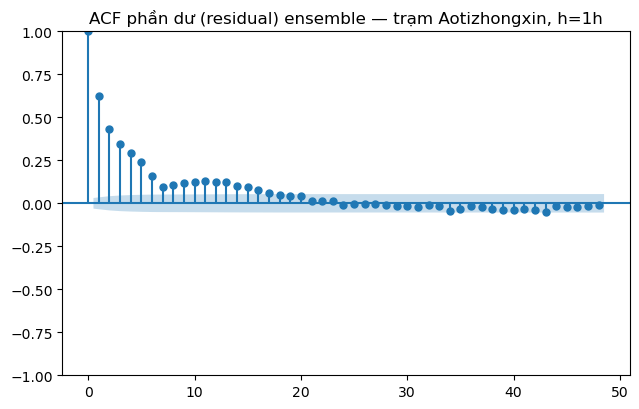

h= 1h  Aotizhongxin     n_test=4136  RMSE residual trước= 24.66  sau= 21.32  cải_thiện= 13.5%
h= 1h  Changping        n_test=4195  RMSE residual trước= 21.43  sau= 20.05  cải_thiện=  6.5%
h= 1h  Dingling         n_test=3619  RMSE residual trước= 18.24  sau= 17.17  cải_thiện=  5.8%
h= 1h  Dongsi           n_test=3911  RMSE residual trước= 28.97  sau= 23.84  cải_thiện= 17.7%


In [ ]:

resid_val_h0 = y_val[:, RESID_HORIZONS[0]] - pred_val_ens[:, RESID_HORIZONS[0]]
sample_station_r = meta_val["station"].iloc[0]
sample_resid_series = pd.Series(resid_val_h0[meta_val["station"].to_numpy() == sample_station_r])

fig, ax = plt.subplots(figsize=(6.5, 4.2))
plot_acf(sample_resid_series, lags=min(48, len(sample_resid_series) // 2 - 1), ax=ax)
ax.set_title(f"ACF phần dư (residual) ensemble — trạm {sample_station_r}, h={RESID_HORIZONS[0]+1}h")
plt.tight_layout()
plt.show()


def station_residual_sequence(meta, resid_values, station):
    sub = pd.DataFrame({"datetime": meta["datetime"].to_numpy(), "resid": resid_values})
    sub = sub[meta["station"].to_numpy() == station].sort_values("datetime").drop_duplicates(subset="datetime")
    return sub["resid"].to_numpy()


def rolling_delayed_correction(val_vals, test_vals, order, delay, min_init=50):
    """Hiệu chỉnh residual đúng nhân-quả cho một horizon có độ trễ báo cáo = delay bước
    (delay = h+1). Chỉ dùng các residual đã "chín" - đã trôi qua đủ delay bước kể từ khi
    phát sinh - để dự báo, tránh dùng residual mà tại thời điểm ra dự báo còn chưa thể biết.
    Trả về mảng correction cùng chiều dài test_vals, hoặc None nếu không đủ dữ liệu."""
    n_val, n_test = len(val_vals), len(test_vals)
    if n_val - delay < min_init or n_test < 1:
        return None

    combined = np.concatenate([val_vals, test_vals])
    init_fit_data = pd.Series(combined[: n_val - delay])           # phần chắc chắn đã "chín" trước khi vào tập test
    reveal_data = combined[n_val - delay: n_val - delay + n_test]  # residual sẽ lần lượt "chín" trong lúc chạy qua test

    resid_std = pd.Series(val_vals).std()
    clip_limit = 5 * resid_std  # phòng vệ số học nếu MLE hội tụ kém

    fit = SARIMAX(init_fit_data, order=order).fit(disp=False)
    corrections = np.full(n_test, np.nan)
    current_fit = fit
    for k in range(n_test):
        current_fit = current_fit.append([reveal_data[k]], refit=False)
        forecast = current_fit.get_forecast(steps=delay).predicted_mean.iloc[-1]
        corrections[k] = np.clip(forecast, -clip_limit, clip_limit)
    return corrections


sarimax_results = {}
series_for_plot = {}
t0 = time.time()
for h in RESID_HORIZONS:
    delay = h + 1
    resid_val_h = y_val[:, h] - pred_val_ens[:, h]
    resid_test_h = y_test[:, h] - pred_test_ens[:, h]
    for station in sorted(meta_val["station"].unique()):
        val_vals = station_residual_sequence(meta_val, resid_val_h, station)
        test_vals = station_residual_sequence(meta_test, resid_test_h, station)
        if len(val_vals) < MIN_VAL_POINTS_SARIMAX or len(test_vals) < 5:
            continue

        try:
            corr_test = rolling_delayed_correction(val_vals, test_vals, SARIMAX_ORDER, delay)
        except Exception as exc:
            print(f"  [bỏ qua] h={h+1}h trạm={station}: {type(exc).__name__}")
            continue
        if corr_test is None:
            print(f"  [bỏ qua] h={h+1}h trạm={station}: validation chưa đủ điểm đã 'chín' (cần > {delay})")
            continue

        s_test = pd.Series(test_vals)
        corr_series = pd.Series(corr_test, index=s_test.index)

        rmse_before = float(np.sqrt(np.mean(s_test.to_numpy() ** 2)))
        rmse_after = float(np.sqrt(np.mean((s_test.to_numpy() - corr_test) ** 2)))
        sarimax_results[(h, station)] = dict(
            rmse_before=rmse_before, rmse_after=rmse_after, n_test=len(s_test),
            corr_test=corr_series, s_test=s_test,
        )
        print(f"h={h+1:>2}h  {station:<16s} n_test={len(s_test):3d}  "
              f"RMSE residual trước={rmse_before:6.2f}  sau={rmse_after:6.2f}  "
              f"cải_thiện={100*(1-rmse_after/rmse_before):5.1f}%")

        if h == RESID_HORIZONS[0]:
            series_for_plot[station] = (s_test, corr_series)

print(f"\nSARIMAX correction xong trong {time.time()-t0:.1f}s cho {len(sarimax_results)} tổ hợp (trạm, horizon)")

if not sarimax_results:
    print("Không có tổ hợp (trạm, horizon) nào đủ dữ liệu validation để fit SARIMAX. "
          "Nếu đang ở FAST_DEV_MODE, hãy tăng DEV_ROWS_PER_STATION hoặc tắt FAST_DEV_MODE rồi chạy lại.")
else:
    keys = list(sarimax_results.keys())
    fig, ax = plt.subplots(figsize=(max(7, len(keys) * 0.9), 4.5))
    xpos = np.arange(len(keys))
    before_vals = [sarimax_results[k]["rmse_before"] for k in keys]
    after_vals = [sarimax_results[k]["rmse_after"] for k in keys]
    ax.bar(xpos - 0.2, before_vals, width=0.4, label="Trước hiệu chỉnh", color="#a0aec0")
    ax.bar(xpos + 0.2, after_vals, width=0.4, label="Sau hiệu chỉnh SARIMAX", color="#2f855a")
    ax.set_xticks(xpos)
    ax.set_xticklabels([f"{st}\nh={h+1}h" for h, st in keys], fontsize=8)
    ax.set_ylabel("RMSE của residual")
    ax.set_title("Hiệu quả residual correction theo trạm & horizon (đã sửa rò rỉ dữ liệu)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    demo_station = next(iter(series_for_plot))
    s_test_demo, corr_test_demo = series_for_plot[demo_station]
    fig, ax = plt.subplots(figsize=(10, 4))
    x_axis = np.arange(len(s_test_demo))
    ax.plot(x_axis, s_test_demo.to_numpy(), color="black", lw=1.2, label="Residual thực tế")
    ax.axhline(0, color="#a0aec0", ls="--", lw=1, label="Ensemble (không hiệu chỉnh)")
    ax.plot(x_axis, corr_test_demo.to_numpy(), color="#c53030", lw=1.2, label="Hiệu chỉnh SARIMAX")
    ax.set_title(f"Trạm {demo_station} — residual {RESID_HORIZONS[0]+1}h: thực tế vs hiệu chỉnh (tập test)")
    ax.set_xlabel("Thứ tự mẫu test (theo thời gian)")
    ax.set_ylabel("Residual (µg/m³)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

### Cell 12: Tổng kết

Bảng dưới so sánh toàn bộ các bước đã thử, theo thứ tự cải tiến dần:
- **Persistence** — baseline ngây thơ, giữ nguyên giá trị hiện tại cho cả 48h.
- **CatBoost** — model chính với feature engineering chuỗi thời gian + weighted loss.
- **LightGBM** — model thứ hai, huấn luyện độc lập qua `MultiOutputRegressor`.
- **Ensemble** — kết hợp CatBoost + LightGBM theo trọng số validation.
- **Ensemble + SARIMAX** — hiệu chỉnh residual cho các horizon trong `RESID_HORIZONS`. RMSE ở hai dòng cuối chỉ tính trên các horizon/trạm đã được hiệu chỉnh (không phải trung bình cả 48h) để so sánh công bằng "trước vs sau" trên đúng cùng một tập con.

Đây là cơ sở để quyết định pipeline cuối cùng đưa vào hệ thống cảnh báo sớm — bao gồm cả việc cân nhắc đánh đổi giữa RMSE tổng thể và tỉ lệ bỏ sót cảnh báo đã phân tích ở Cell 9.

                              Model      RMSE                  Ghi chú
               Persistence baseline 99.965773              Toàn bộ 48h
                CatBoost (weighted) 84.942295              Toàn bộ 48h
                           LightGBM 85.131678              Toàn bộ 48h
       Ensemble (CatBoost+LightGBM) 84.605896              Toàn bộ 48h
Ensemble, chỉ horizon đã hiệu chỉnh 80.695950 Chỉ [1, 12, 24, 36, 48]h
      Ensemble + SARIMAX correction 78.524745 Chỉ [1, 12, 24, 36, 48]h


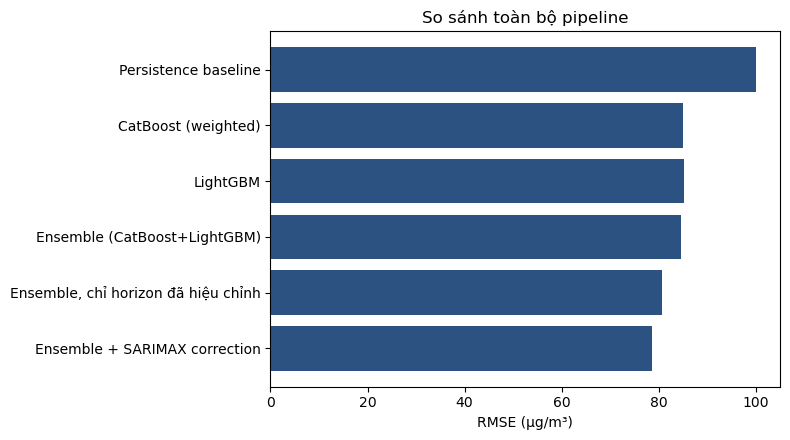

In [ ]:
if sarimax_results:
    resid_before_all = np.concatenate([sarimax_results[k]["s_test"].to_numpy() for k in sarimax_results])
    resid_after_all = np.concatenate([
        (sarimax_results[k]["s_test"] - sarimax_results[k]["corr_test"]).to_numpy() for k in sarimax_results
    ])
    rmse_ens_subset = float(np.sqrt(np.mean(resid_before_all ** 2)))
    rmse_ens_sarimax_subset = float(np.sqrt(np.mean(resid_after_all ** 2)))
else:
    rmse_ens_subset = float("nan")
    rmse_ens_sarimax_subset = float("nan")

summary = pd.DataFrame([
    {"Model": "Persistence baseline", "RMSE": rmse_baseline, "Ghi chú": "Toàn bộ 48h"},
    {"Model": "CatBoost (weighted)", "RMSE": rmse_cb, "Ghi chú": "Toàn bộ 48h"},
    {"Model": "LightGBM", "RMSE": rmse_lgbm, "Ghi chú": "Toàn bộ 48h"},
    {"Model": "Ensemble (CatBoost+LightGBM)", "RMSE": rmse_ens, "Ghi chú": "Toàn bộ 48h"},
    {"Model": "Ensemble, chỉ horizon đã hiệu chỉnh", "RMSE": rmse_ens_subset, "Ghi chú": f"Chỉ {[h+1 for h in RESID_HORIZONS]}h"},
    {"Model": "Ensemble + SARIMAX correction", "RMSE": rmse_ens_sarimax_subset, "Ghi chú": f"Chỉ {[h+1 for h in RESID_HORIZONS]}h"},
])
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(summary["Model"][::-1], summary["RMSE"][::-1], color="#2c5282")
ax.set_xlabel("RMSE (µg/m³)")
ax.set_title("So sánh toàn bộ pipeline")
plt.tight_layout()
plt.show()

Tập dữ liệu  CatBoost  LightGBM  Ensemble
      Train     59.52     56.51     57.55
 Validation     77.05     77.00     76.67
       Test     84.94     85.13     84.61

Phân tách khoảng cách: train->val là OVERFITTING, val->test là DỊCH CHUYỂN PHÂN PHỐI
(val và test đều là dữ liệu chưa từng thấy; nếu val->test vẫn lớn thì đó là do tập test
 rơi vào giai đoạn ô nhiễm nặng hơn, không phải do model học thuộc tập train)

CatBoost  : train->val  +29.4% (trước:  +39.7%)   |  val->test +10.2% (trước:  +9.5%)   |  test RMSE 84.94 (trước: 85.09)
LightGBM  : train->val  +36.3% (trước: +143.7%)  <-- overfitting rõ   |  val->test +10.6% (trước:  +9.8%)   |  test RMSE 85.13 (trước: 87.62)
Ensemble  : train->val  +33.2% (trước:  +83.6%)  <-- overfitting rõ   |  val->test +10.4% (trước:  +9.4%)   |  test RMSE 84.61 (trước: 85.30)


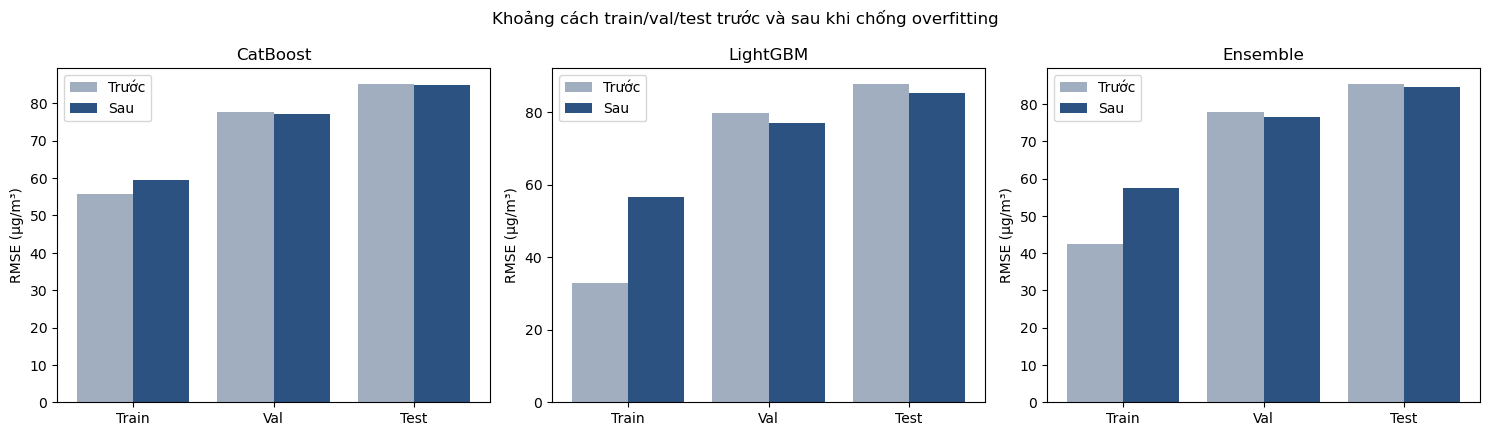

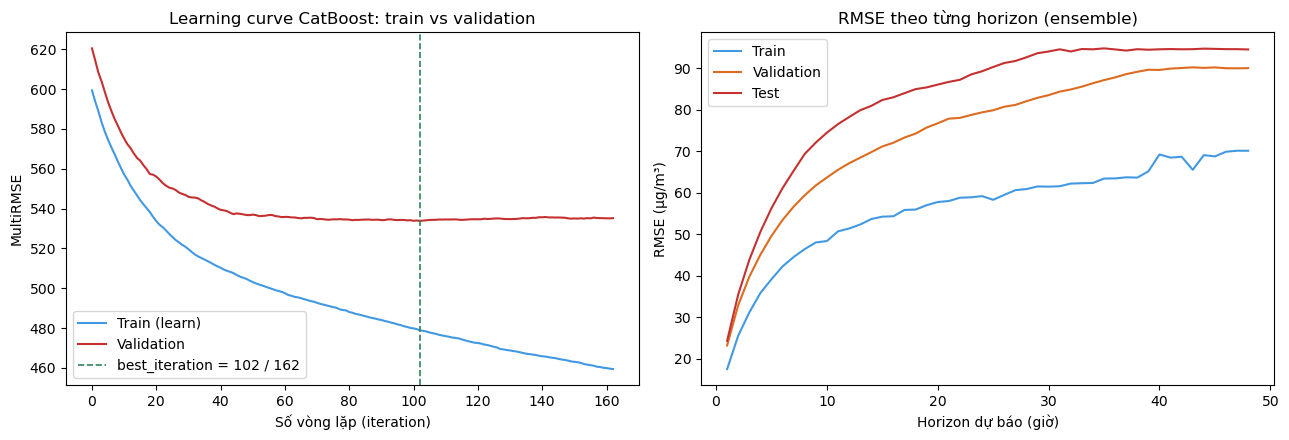

In [ ]:
pred_train_cb = cb_model.predict(x_train)
pred_train_lgbm = lgbm_predict(x_train)
pred_train_ens = ensemble_weights[0] * pred_train_cb + ensemble_weights[1] * pred_train_lgbm


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


comparison_table = pd.DataFrame([
    {"Tập dữ liệu": "Train", "CatBoost": rmse(y_train, pred_train_cb),
     "LightGBM": rmse(y_train, pred_train_lgbm), "Ensemble": rmse(y_train, pred_train_ens)},
    {"Tập dữ liệu": "Validation", "CatBoost": rmse(y_val, pred_val_cb),
     "LightGBM": rmse(y_val, pred_val_lgbm), "Ensemble": rmse(y_val, pred_val_ens)},
    {"Tập dữ liệu": "Test", "CatBoost": rmse(y_test, pred_test_cb),
     "LightGBM": rmse(y_test, pred_test_lgbm), "Ensemble": rmse(y_test, pred_test_ens)},
])
print(comparison_table.round(2).to_string(index=False))

# Kết quả TRƯỚC khi áp dụng các biện pháp chống overfitting (để đối chiếu trong báo cáo)
before = {"CatBoost": (55.62, 77.68, 85.09), "LightGBM": (32.75, 79.82, 87.62),
          "Ensemble": (42.47, 77.97, 85.30)}

print("\nPhân tách khoảng cách: train->val là OVERFITTING, val->test là DỊCH CHUYỂN PHÂN PHỐI")
print("(val và test đều là dữ liệu chưa từng thấy; nếu val->test vẫn lớn thì đó là do tập test")
print(" rơi vào giai đoạn ô nhiễm nặng hơn, không phải do model học thuộc tập train)\n")
for name in ["CatBoost", "LightGBM", "Ensemble"]:
    tr, va, te = [comparison_table.loc[i, name] for i in range(3)]
    b_tr, b_va, b_te = before[name]
    overfit_gap = (va / tr - 1) * 100
    shift_gap = (te / va - 1) * 100
    flag = "  <-- overfitting rõ" if overfit_gap > 30 else ""
    print(f"{name:10s}: train->val {overfit_gap:+6.1f}% (trước: {(b_va/b_tr-1)*100:+6.1f}%){flag}"
          f"   |  val->test {shift_gap:+5.1f}% (trước: {(b_te/b_va-1)*100:+5.1f}%)"
          f"   |  test RMSE {te:.2f} (trước: {b_te:.2f})")

# --- Biểu đồ 1: RMSE train/val/test, trước vs sau ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
x_pos = np.arange(3)
for ax, name in zip(axes, ["CatBoost", "LightGBM", "Ensemble"]):
    after_vals = [comparison_table.loc[i, name] for i in range(3)]
    ax.bar(x_pos - 0.2, before[name], 0.4, label="Trước", color="#a0aec0")
    ax.bar(x_pos + 0.2, after_vals, 0.4, label="Sau", color="#2c5282")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(["Train", "Val", "Test"])
    ax.set_ylabel("RMSE (µg/m³)")
    ax.set_title(name)
    ax.legend()
plt.suptitle("Khoảng cách train/val/test trước và sau khi chống overfitting")
plt.tight_layout()
plt.show()

# --- Biểu đồ 2: learning curve CatBoost ---
evals = cb_model.get_evals_result()
learn_curve = evals["learn"]["MultiRMSE"]
val_curve = evals["validation"]["MultiRMSE"]
best_iter = cb_model.get_best_iteration()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(learn_curve, label="Train (learn)", color="#4299e1")
axes[0].plot(val_curve, label="Validation", color="#c53030")
axes[0].axvline(best_iter, color="#2f855a", ls="--", lw=1.2,
                label=f"best_iteration = {best_iter} / {len(learn_curve)-1}")
axes[0].set_xlabel("Số vòng lặp (iteration)")
axes[0].set_ylabel("MultiRMSE")
axes[0].set_title("Learning curve CatBoost: train vs validation")
axes[0].legend()

# --- Biểu đồ 3: RMSE theo từng horizon — sai số tăng dần theo tầm dự báo là điều BÌNH THƯỜNG,
#     nhưng nếu train phẳng còn test dốc đứng thì đó là dấu hiệu overfit ở horizon xa.
h_axis = np.arange(1, HORIZON + 1)
for label, y_true, y_pred, color in [
    ("Train", y_train, pred_train_ens, "#4299e1"),
    ("Validation", y_val, pred_val_ens, "#dd6b20"),
    ("Test", y_test, pred_test_ens, "#c53030"),
]:
    axes[1].plot(h_axis, np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0)), label=label, color=color)
axes[1].set_xlabel("Horizon dự báo (giờ)")
axes[1].set_ylabel("RMSE (µg/m³)")
axes[1].set_title("RMSE theo từng horizon (ensemble)")
axes[1].legend()
plt.tight_layout()
plt.show()


### Đánh giá RMSE so với Biên độ Dao động Tự nhiên của Dữ liệu (RMSE vs. Data Amplitude)

Một giá trị RMSE (ví dụ $83.5\,\mu g/m^3$) không mang nhiều ý nghĩa nếu đứng độc lập: nó chỉ được đánh giá là chính xác hay sai số lớn khi đối chiếu trực tiếp với **quy mô biến thiên tự nhiên (amplitude / variability)** của chuỗi dữ liệu gốc.

Dưới đây là 4 chỉ số chuẩn hoá biên độ (Normalized RMSE - NRMSE):
1. **Biên độ toàn phần ($NRMSE_{range} = \frac{RMSE}{y_{max} - y_{min}} \times 100\%$):** Tỷ lệ sai số so với toàn bộ dải biến thiên từ đáy sạch nhất đến đỉnh bão khói bụi.
2. **Độ lệch chuẩn ($NRMSE_{std} = \frac{RMSE}{\sigma_y} \times 100\%$):** Đo lường sai số so với độ phân tán tự nhiên của dữ liệu xung quanh giá trị kỳ vọng ($NRMSE_{std} \ge 100\%$ nghĩa là mô hình không tốt hơn giá trị trung bình).
3. **Biên độ tứ phân vị ($NRMSE_{IQR} = \frac{RMSE}{Q_{75} - Q_{25}} \times 100\%$):** Thước đo biên độ bền vững (robust amplitude) đại diện cho 50% mẫu lõi, loại trừ các đỉnh dị biệt.
4. **Hệ số biến thiên sai số ($NRMSE_{mean} = CV(RMSE) = \frac{RMSE}{\bar{y}} \times 100\%$):** Tỷ lệ phần trăm sai số so với nồng độ PM2.5 trung bình.

In [ ]:
# 1. Thước đo biên độ dữ liệu trên tập Test
y_test_all = y_test.reshape(-1)
data_min = float(np.min(y_test_all))
data_max = float(np.max(y_test_all))
data_range = data_max - data_min        # Biên độ đỉnh - đáy
data_q25 = float(np.percentile(y_test_all, 25))
data_q75 = float(np.percentile(y_test_all, 75))
data_iqr = data_q75 - data_q25          # Biên độ IQR
data_std = float(np.std(y_test_all))    # Độ lệch chuẩn σ
data_mean = float(np.mean(y_test_all))  # Giá trị trung bình µ

print('=' * 65)
print('BIÊN ĐỘ DAO ĐỘNG CỦA NỒNG ĐỘ PM2.5 TRÊN TẬP TEST (µg/m³):')
print('=' * 65)
print(f'  - Giá trị min / max:               {data_min:.1f} -> {data_max:.1f} µg/m³')
print(f'  - Biên độ toàn phần (Range):       {data_range:.1f} µg/m³')
print(f'  - Biên độ tứ phân vị (IQR, Q75-25): {data_iqr:.1f} µg/m³ (Q25={data_q25:.1f}, Q75={data_q75:.1f})')
print(f'  - Độ lệch chuẩn (Std, σ):          {data_std:.1f} µg/m³')
print(f'  - Nồng độ trung bình (Mean, µ):    {data_mean:.1f} µg/m³')
print('=' * 65)

# 2. Bảng đối sánh RMSE chuẩn hóa của các mô hình
models_to_compare = {
    'Persistence': baseline_test,
    'CatBoost': pred_test_cb,
    'LightGBM': pred_test_lgbm,
    'Ensemble': pred_test_ens
}

rows_amp = []
for m_name, preds in models_to_compare.items():
    rmse_m = float(np.sqrt(np.mean((y_test - preds) ** 2)))
    r2_m = float(r2_score(y_test.reshape(-1), preds.reshape(-1)))
    rows_amp.append({
        'Mô hình': m_name,
        'RMSE (µg/m³)': round(rmse_m, 2),
        'NRMSE / Range (%)': round((rmse_m / data_range) * 100.0, 2),
        'NRMSE / Std (σ, %)': round((rmse_m / data_std) * 100.0, 2),
        'NRMSE / Mean (CV, %)': round((rmse_m / data_mean) * 100.0, 2),
        'NRMSE / IQR (%)': round((rmse_m / data_iqr) * 100.0, 2),
        'R² Score': round(r2_m, 4)
    })

df_amp_nb = pd.DataFrame(rows_amp)
display(df_amp_nb)

# 3. Biểu đồ trực quan hoá
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị A: So sánh NRMSE đa thang đo
x_idx = np.arange(len(df_amp_nb))
w = 0.2
axes[0].bar(x_idx - 1.5 * w, df_amp_nb['NRMSE / Range (%)'], w, label='NRMSE / Range', color='#4299e1')
axes[0].bar(x_idx - 0.5 * w, df_amp_nb['NRMSE / Std (σ, %)'], w, label='NRMSE / Std (σ)', color='#48bb78')
axes[0].bar(x_idx + 0.5 * w, df_amp_nb['NRMSE / Mean (CV, %)'], w, label='NRMSE / Mean (CV)', color='#ed8936')
axes[0].bar(x_idx + 1.5 * w, df_amp_nb['NRMSE / IQR (%)'], w, label='NRMSE / IQR', color='#9f7aea')
axes[0].axhline(100.0, ls='--', color='#e53e3e', lw=1.2, alpha=0.8, label='Ngưỡng 100% (Sai số = Biên độ)')
axes[0].set_xticks(x_idx)
axes[0].set_xticklabels(df_amp_nb['Mô hình'], rotation=18, ha='right', fontsize=9)
axes[0].set_ylabel('Tỷ lệ sai số chuẩn hoá (%)')
axes[0].set_title('Sai số RMSE chuẩn hoá theo các thước đo biên độ (Tập Test)')
axes[0].legend(fontsize=8, loc='upper left')

# Đồ thị B: Tỷ lệ NRMSE theo từng Horizon so với độ lệch chuẩn và IQR
std_h = np.std(y_test, axis=0)
iqr_h = np.percentile(y_test, 75, axis=0) - np.percentile(y_test, 25, axis=0)
rmse_ens_h = np.sqrt(np.mean((y_test - pred_test_ens) ** 2, axis=0))
nrmse_std_curve = (rmse_ens_h / std_h) * 100.0
nrmse_iqr_curve = (rmse_ens_h / iqr_h) * 100.0

h_steps = np.arange(1, HORIZON + 1)
axes[1].plot(h_steps, nrmse_std_curve, label='NRMSE(h) / σ(h) [So với độ lệch chuẩn]', color='#2b6cb0', lw=2.2)
axes[1].plot(h_steps, nrmse_iqr_curve, label='NRMSE(h) / IQR(h) [So với khoảng tứ phân vị]', color='#805ad5', lw=2.2)
axes[1].axhline(100.0, ls='--', color='#e53e3e', lw=1.5, label='100% Biên độ (Ngưỡng bão hòa không còn giá trị dự báo)')
axes[1].fill_between(h_steps, nrmse_std_curve, 100.0, where=(nrmse_std_curve < 100.0), color='#bee3f8', alpha=0.45, label='Vùng giá trị gia tăng của mô hình')
axes[1].set_xlabel('Horizon dự báo (giờ tới)')
axes[1].set_ylabel('Tỷ lệ sai số so với biên độ (%)')
axes[1].set_title('Diễn biến tỷ lệ sai số Ensemble / Biên độ theo từng bước thời gian')
axes[1].legend(fontsize=8.5, loc='lower right')

plt.tight_layout()
plt.show()

### Thử nghiệm Hồi quy Phân vị (Quantile Loss & Probabilistic Forecasting)

Mô hình tối ưu hóa theo **MSE (L2 loss)** chỉ dự báo giá trị kỳ vọng trung bình $\mathbb{E}[y|X]$. Do đó, khi xảy ra các đợt bùng phát ô nhiễm nghiêm trọng ($PM2.5 \ge 250\,\mu g/m^3$), hàm MSE phạt nặng việc dự báo vượt và có xu hướng kéo dự báo về vùng an toàn, dẫn đến hiện tượng **underprediction nghiêm trọng (thường thiếu từ 75% đến 90% trường hợp)**.

Trong bài toán y tế cộng đồng và cảnh báo sớm, việc dự báo thiếu một đợt ô nhiễm nguy hiểm gây hậu quả nặng nề hơn rất nhiều so với việc cảnh báo hơi cao (Asymmetric Risk). **Hồi quy Phân vị (Quantile Loss / Pinball Loss)** giải quyết trực tiếp bài toán này:

$$\mathcal{L}_q(y, \hat{y}) = \max(q(y - \hat{y}), (1 - q)(\hat{y} - y))$$

Ta huấn luyện LightGBM phân vị với:
- $q=0.10$: Cận dưới (Lower Bound, độ phủ kỳ vọng 10%).
- $q=0.50$: Trung vị có điều kiện (Conditional Median, bền vững trước ngoại lai).
- $q=0.90$: Cận trên cảnh báo sớm rủi ro cao (High-Risk Upper Bound, độ phủ kỳ vọng 90%).
- Dải $[q_{0.10}, q_{0.90}]$ tạo thành **khoảng dự báo 80% (80% Prediction Interval)** tin cậy.

In [ ]:
# 1. Đào tạo Quantile Regressors (LightGBM) cho mốc dự báo t+24h (mốc cảnh báo 24 giờ)
quantiles = [0.10, 0.50, 0.90]
TARGET_H_IDX = 23   # Horizon 24h
H_LABEL = 24

print(f'--- Huấn luyện Quantile Regressors (LightGBM) cho mốc dự báo t+{H_LABEL}h ---')
t0 = time.time()
q_models = {}

for q in quantiles:
    t_q = time.time()
    qm = LGBMRegressor(
        objective='quantile',
        alpha=q,
        n_estimators=150,
        learning_rate=0.08,
        num_leaves=31,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
    qm.fit(x_train, y_train[:, TARGET_H_IDX])
    q_models[q] = qm
    print(f'  Model q={q:.2f} hoàn thành trong {time.time()-t_q:.2f}s')

# Dự báo trên tập Test
y_test_h = y_test[:, TARGET_H_IDX]
preds_q_test = {q: q_models[q].predict(x_test) for q in quantiles}

# Dự báo chuẩn MSE
pred_mse_test = pred_test_lgbm[:, TARGET_H_IDX]

# 2. Đánh giá Độ phủ thực nghiệm (Empirical Coverage) và Pinball Loss trên tập Test
q_eval_rows = []
for q in quantiles:
    y_p = preds_q_test[q]
    cov = float(np.mean(y_test_h <= y_p) * 100)
    pinball = float(np.mean(np.maximum(q * (y_test_h - y_p), (1 - q) * (y_p - y_test_h))))
    mae = float(np.mean(np.abs(y_test_h - y_p)))
    rmse_val = float(np.sqrt(np.mean((y_test_h - y_p) ** 2)))
    mean_bias = float(np.mean(y_p - y_test_h))
    q_eval_rows.append({
        'Quantile': f'q={q:.2f}',
        'Mục tiêu lý thuyết (%)': f'{q*100:.0f}%',
        'Độ phủ thực nghiệm (%)': f'{cov:.2f}%',
        'Pinball Loss': round(pinball, 3),
        'MAE (µg/m³)': round(mae, 2),
        'RMSE (µg/m³)': round(rmse_val, 2),
        'Mean Bias (µg/m³)': round(mean_bias, 2)
    })

df_q_eval = pd.DataFrame(q_eval_rows)
print('\n--- Bảng Đánh giá Hồi quy Phân vị trên tập Test (t+24h) ---')
display(df_q_eval)

# 3. Phân tích cắt giảm underprediction trên các đỉnh ô nhiễm cực đoan (>= 95th percentile)
p95_val = float(np.percentile(y_test_h, 95))
ext_idx = np.nonzero(y_test_h >= p95_val)[0]
n_ext = len(ext_idx)

under_mse = float(np.mean(pred_mse_test[ext_idx] < y_test_h[ext_idx]) * 100)
under_q50 = float(np.mean(preds_q_test[0.50][ext_idx] < y_test_h[ext_idx]) * 100)
under_q90 = float(np.mean(preds_q_test[0.90][ext_idx] < y_test_h[ext_idx]) * 100)

mean_under_err_mse = float(np.mean(y_test_h[ext_idx] - pred_mse_test[ext_idx]))
mean_under_err_q90 = float(np.mean(y_test_h[ext_idx] - preds_q_test[0.90][ext_idx]))

print(f'\n--- So sánh trên nhóm ô nhiễm cực đoan (PM2.5 >= 95th percentile = {p95_val:.1f} µg/m³, N={n_ext}) ---')
print(f'  • Mô hình chuẩn MSE (L2)  -> Tỷ lệ dự báo thiếu: {under_mse:.1f}% | Sai số thiếu hụt trung bình: {mean_under_err_mse:.1f} µg/m³')
print(f'  • Mô hình phân vị q=0.50   -> Tỷ lệ dự báo thiếu: {under_q50:.1f}%')
print(f'  • Mô hình phân vị q=0.90   -> Tỷ lệ dự báo thiếu: {under_q90:.1f}% | Sai số thiếu hụt trung bình: {mean_under_err_q90:.1f} µg/m³')
print(f'  => Cắt giảm rủi ro underprediction: {under_mse - under_q90:.1f} điểm % nhờ hàm mất mát bất đối xứng!')

# 4. Trực quan hoá 3 khung hình (Fan Chart, Calibration Curve, Extreme Bias Shift)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: Fan Chart
chosen_station = meta_test['station'].unique()[0]
station_mask = (meta_test['station'] == chosen_station).to_numpy()
sub_indices = np.nonzero(station_mask)[0]
window_len = min(96, len(sub_indices))
best_start = 0
max_sum = 0
for s_idx in range(0, len(sub_indices) - window_len, 24):
    cur_sum = np.sum(y_test_h[sub_indices[s_idx:s_idx+window_len]])
    if cur_sum > max_sum:
        max_sum = cur_sum
        best_start = s_idx

plot_slice = sub_indices[best_start:best_start+window_len]
time_hours = np.arange(len(plot_slice))

ax1 = axes[0]
ax1.fill_between(time_hours, preds_q_test[0.10][plot_slice], preds_q_test[0.90][plot_slice], 
                 color='#38bdf8', alpha=0.35, label='Khoảng bất định 80% [q=0.10, q=0.90]')
ax1.plot(time_hours, preds_q_test[0.50][plot_slice], color='#0284c7', linestyle='--', linewidth=2, label='Trung vị dự báo (q=0.50)')
ax1.plot(time_hours, pred_mse_test[plot_slice], color='#ef4444', linestyle=':', linewidth=2, label='Dự báo điểm MSE (L2)')
ax1.plot(time_hours, y_test_h[plot_slice], color='#0f172a', linewidth=2.2, label='PM2.5 Thực tế (Ground Truth)')
ax1.set_title(f'Fan Chart Dự báo Bất định 96h tại trạm {chosen_station} (t+24h)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Thời gian quan sát (Giờ liên tục)', fontsize=10)
ax1.set_ylabel('Nồng độ PM2.5 (µg/m³)', fontsize=10)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3)

# Subplot 2: Calibration Curve
ax2 = axes[1]
th_q = [0.10, 0.50, 0.90]
emp_cov = [float(np.mean(y_test_h <= preds_q_test[q])) for q in th_q]
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Cân chỉnh lý tưởng (Ideal)')
ax2.scatter(th_q, emp_cov, color='#0284c7', s=100, zorder=5)
ax2.plot(th_q, emp_cov, color='#0284c7', linewidth=2, marker='o', label='Độ phủ thực tế trên Test')
for t, e in zip(th_q, emp_cov):
    ax2.annotate(f'{e*100:.1f}%', (t, e), textcoords='offset points', xytext=(0, 10), ha='center', fontweight='bold', fontsize=10)
ax2.set_title('Đường cong Cân chỉnh Phân vị (Calibration Curve)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Phân vị mục tiêu danh nghĩa (Theoretical Quantile)', fontsize=10)
ax2.set_ylabel('Tần suất tích luỹ thực nghiệm P(y <= ŷ_q)', fontsize=10)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Subplot 3: Phân phối phần dư trên đỉnh cực đoan
ax3 = axes[2]
res_mse_ext = y_test_h[ext_idx] - pred_mse_test[ext_idx]
res_q90_ext = y_test_h[ext_idx] - preds_q_test[0.90][ext_idx]
ax3.hist(res_mse_ext, bins=25, alpha=0.6, color='#ef4444', label=f'MSE (Thiếu tb: {mean_under_err_mse:.1f} µg/m³)')
ax3.hist(res_q90_ext, bins=25, alpha=0.6, color='#10b981', label=f'q=0.90 (Thiếu tb: {mean_under_err_q90:.1f} µg/m³)')
ax3.axvline(0, color='black', linestyle='--', linewidth=1.2)
ax3.set_title('Phần dư Dự báo trên Đỉnh Ô nhiễm Cực đoan (y >= p95)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Sai số dự báo: y_true - y_pred (µg/m³)', fontsize=10)
ax3.set_ylabel('Số lượng mẫu quan sát', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Cell 14: Các biện pháp chống overfitting — tổng kết cho báo cáo

| # | Biện pháp | Áp dụng ở đâu | Chống overfitting bằng cách nào |
|---|-----------|---------------|----------------------------------|
| 1 | **Purged split** (đệm 48h giữa train/val/test) | Cell 7 | Cửa sổ 48h ở cuối tập train có target trải sang đầu tập validation. Không đệm thì validation bị "nhìn trộm" → điểm validation lạc quan giả và early stopping dừng sai chỗ. |
| 2 | **Early stopping theo validation** | CatBoost + cả 48 model LightGBM | Dừng thêm cây ngay khi validation ngừng cải thiện, thay vì luôn chạy đủ số cây đặt trước. |
| 3 | **Giảm độ phức tạp cây** (`depth` 8→6, `num_leaves` 63→31, `min_child_samples=200`) | Cell config | Cây nông/ít lá hơn không đủ "chỗ" để ghi nhớ từng mẫu nhiễu. |
| 4 | **Tăng chính quy hoá** (`l2_leaf_reg` 5→12, `reg_alpha/reg_lambda` cho LightGBM) | Cell config | Phạt trực tiếp các giá trị lá lớn — model phải có bằng chứng mạnh mới dám dự báo lệch nhiều. |
| 5 | **Lấy mẫu ngẫu nhiên hàng & cột** (`subsample=0.8` + `subsample_freq=1`, `rsm`/`colsample_bytree`) | Cell config | Mỗi cây thấy một phần dữ liệu khác nhau → các cây ít tương quan → phương sai tổng thể giảm. Lưu ý: bản cũ đặt `subsample=0.8` nhưng **thiếu `subsample_freq`** nên tham số này hoàn toàn vô hiệu. |
| 6 | **Trọng số ensemble chọn bằng validation** (quét alpha) | Cell 10 | Công thức nghịch đảo RMSE cũ ép LightGBM giữ 49% tiếng nói dù nó đang overfit — đó là lý do ensemble cũ (85.30) *tệ hơn* CatBoost đơn lẻ (85.09). Quét alpha cho phép validation tự loại bỏ model kém. |
| 7 | **Tách bạch overfitting với dịch chuyển phân phối** | Cell cuối | Chênh lệch train→val mới là overfitting; chênh lệch val→test là do tập test rơi vào mùa đông 2016-2017 ô nhiễm nặng hơn. Gộp chung hai thứ này vào một con số "test so với train" sẽ chẩn đoán sai nguyên nhân. |



### Walk-forward validation: kết quả có ổn định qua các giai đoạn không?

Split đơn (Cell 7) chỉ đánh giá model trên **một** giai đoạn test cố định — Cell tổng kết ở trên đã chỉ ra test rơi đúng vào mùa đông 2016-2017 nhiều đợt ô nhiễm nặng, nên phần chênh lệch val→test được xem là dịch chuyển phân phối. Walk-forward validation kiểm chứng trực tiếp giả thuyết đó: huấn luyện lại trên 4 giai đoạn khác nhau (mỗi fold train mở rộng dần theo thời gian, test trên đoạn kế tiếp, vẫn giữ khoảng đệm `PURGE_HOURS` để tránh rò rỉ) — nếu RMSE dao động mạnh giữa các fold theo đúng kiểu theo mùa, đó là bằng chứng ủng hộ "dịch chuyển phân phối"; nếu RMSE ổn định quanh một giá trị, model tổng quát hoá tốt qua thời gian.

**Phạm vi:** chỉ chạy cho CatBoost (model chính) để giữ thời gian chạy hợp lý — lặp lại cho LightGBM (48 model/fold) sẽ tốn gấp nhiều lần. Mỗi fold dùng lại `best_iteration` đã chọn từ model chính (qua early stopping) thay vì tự early-stop riêng, để không cần tách thêm một tập validation lồng bên trong mỗi fold.

Fold 1: test 2013-11-10 -> 2014-08-22  n_train=63,204  n_test=63,759  RMSE=73.17  (92s)
Fold 2: test 2014-08-22 -> 2015-06-23  n_train=127,099  n_test=63,763  RMSE=67.08  (246s)
Fold 3: test 2015-06-23 -> 2016-05-13  n_train=190,724  n_test=63,760  RMSE=75.47  (468s)
Fold 4: test 2016-05-13 -> 2017-02-26  n_train=254,609  n_test=63,762  RMSE=72.58  (759s)

RMSE trung bình các fold: 72.07  (độ lệch chuẩn: 3.55)
So với RMSE CatBoost trên split đơn (test cố định): 84.94


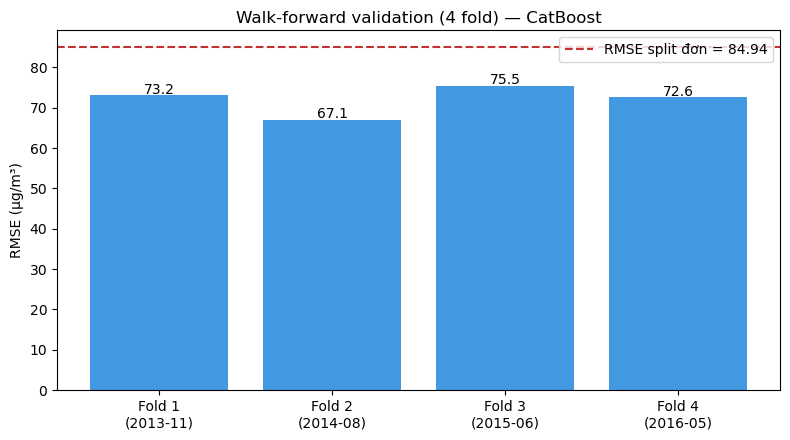

In [ ]:
N_WALKFORWARD_FOLDS = 4
wf_iterations = cb_model.get_best_iteration() + 1


def make_walkforward_folds(dt_all, n_folds=N_WALKFORWARD_FOLDS, purge_hours=PURGE_HOURS):
    """Chia mốc thời gian thành n_folds+1 đoạn liên tiếp; mỗi fold: train = mọi đoạn
    trước đó (mở rộng dần), test = đoạn kế tiếp, có khoảng đệm purge_hours ở ranh giới."""
    n_total = len(dt_all)
    edges = np.linspace(0, n_total, n_folds + 2, dtype=int)
    gap = pd.Timedelta(hours=purge_hours)
    folds = []
    for i in range(1, n_folds + 1):
        t_test_start = dt_all.iloc[edges[i]]
        t_test_end = dt_all.iloc[min(edges[i + 1], n_total - 1)]
        train_mask = (dt_all < t_test_start - gap).to_numpy()
        test_mask = ((dt_all >= t_test_start) & (dt_all < t_test_end)).to_numpy()
        folds.append((train_mask, test_mask, t_test_start, t_test_end))
    return folds


dt_all_sorted = meta_all["datetime"]
wf_folds = make_walkforward_folds(dt_all_sorted)

wf_params = dict(CATBOOST_PARAMS)
wf_params["iterations"] = wf_iterations

wf_results = []
t0 = time.time()
for fold_i, (train_mask, test_mask, t_start, t_end) in enumerate(wf_folds, start=1):
    if train_mask.sum() < 200 or test_mask.sum() < 50:
        print(f"Fold {fold_i}: bỏ qua (không đủ dữ liệu, train={train_mask.sum()} test={test_mask.sum()})")
        continue
    model_fold = CatBoostRegressor(**wf_params)
    model_fold.fit(x_all[train_mask], y_all[train_mask], sample_weight=weights_all[train_mask])
    pred_fold = model_fold.predict(x_all[test_mask])
    rmse_fold = float(np.sqrt(np.mean((y_all[test_mask] - pred_fold) ** 2)))
    wf_results.append({"fold": fold_i, "test_start": t_start, "test_end": t_end,
                        "n_train": int(train_mask.sum()), "n_test": int(test_mask.sum()), "rmse": rmse_fold})
    print(f"Fold {fold_i}: test {t_start.date()} -> {t_end.date()}  n_train={train_mask.sum():,}  "
          f"n_test={test_mask.sum():,}  RMSE={rmse_fold:.2f}  ({time.time()-t0:.0f}s)")

wf_df = pd.DataFrame(wf_results)
print(f"\nRMSE trung bình các fold: {wf_df['rmse'].mean():.2f}  (độ lệch chuẩn: {wf_df['rmse'].std():.2f})")
print(f"So với RMSE CatBoost trên split đơn (test cố định): {rmse_cb:.2f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar([f"Fold {r['fold']}\n({r['test_start'].strftime('%Y-%m')})" for r in wf_results],
              wf_df["rmse"], color="#4299e1")
ax.axhline(rmse_cb, color="#c53030", ls="--", label=f"RMSE split đơn = {rmse_cb:.2f}")
for b, v in zip(bars, wf_df["rmse"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.3, f"{v:.1f}", ha="center")
ax.set_ylabel("RMSE (µg/m³)")
ax.set_title(f"Walk-forward validation ({len(wf_results)} fold) — CatBoost")
ax.legend()
plt.tight_layout()
plt.show()